# Multivariate Analysis of Expected UK/US IRD (Proxied Using 2Y Bond Yield) Against GBP/USD

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import statsmodels.api as sm

## Processing

### Load Data

In [2]:
# Load dtype map
dtype_map = pd.read_csv("../data/features/gbpusd/v1_11-09-25/gbpusd_features_dtypes_as_of_110925.csv").to_dict()

# Convert dtype strings to actual Python types
dtype_map = {
    col: eval(dtype_str) if "float" in dtype_str or "int" in dtype_str else "object"
    for col, dtype_str in dtype_map.items()
}

# Load cleaned data with correct types
gbpusd = pd.read_csv("../data/features/gbpusd/v1_11-09-25/gbpusd_features_as_of_110925.csv", dtype=dtype_map, parse_dates=[0], index_col=0)

In [3]:
gbpusd.head()

,gbp_usd_noon_rate,simple_return,log_return
date,,,
1971-01-04,2.3938,NaN,NaN
1971-01-05,2.3949,0.000460,0.000459
1971-01-06,2.3967,0.000752,0.000751
1971-01-07,2.3963,-0.000167,-0.000167
1971-01-08,2.3972,0.000376,0.000376


In [4]:
# Load dtype map
dtype_map = pd.read_csv("../data/features/spread/v1_11-09-25/spread_features_dtypes_as_of_110925.csv").to_dict()

# Convert dtype strings to actual Python types
dtype_map = {
    col: eval(dtype_str) if "float" in dtype_str or "int" in dtype_str else "object"
    for col, dtype_str in dtype_map.items()
}

# Load cleaned data with correct types
spread = pd.read_csv("../data/features/spread/v1_11-09-25/spread_features_as_of_110925.csv", dtype=dtype_map, parse_dates=[0], index_col=0)

In [5]:
spread.head()

,uk_2y,us_2y,spread_bp,spread_abs_change_daily,spread_bp_z_score,spread_abs_change_daily_z_score
date,,,,,,
1979-01-01,11.96,9.98,198.0,NaN,NaN,NaN
1979-01-02,11.96,10.00,196.0,-2.0,NaN,NaN
1979-01-03,11.99,9.98,201.0,5.0,NaN,NaN
1979-01-04,11.94,9.88,206.0,5.0,NaN,NaN
1979-01-05,11.89,9.87,202.0,-4.0,NaN,NaN


### Alignment

In [6]:
start = max(gbpusd.index.min(), spread.index.min())
end   = min(gbpusd.index.max(), spread.index.max())
calendar = pd.date_range(start=start, end=end, freq="B")

In [7]:
gbpusd = gbpusd.reindex(calendar)
spread = spread.reindex(calendar)

In [8]:
print(gbpusd["gbp_usd_noon_rate"].isna().sum())
print(spread["spread_bp"].isna().sum())

0
0


### Lags

In [9]:
spread["30d_lagged_spread_bp"] = spread["spread_bp"].shift(30)
spread["7d_lagged_spread_bp"] = spread["spread_bp"].shift(7)
spread["1d_lagged_spread_bp"] = spread["spread_bp"].shift(1)
spread.head()

,uk_2y,us_2y,spread_bp,spread_abs_change_daily,spread_bp_z_score,spread_abs_change_daily_z_score,30d_lagged_spread_bp,7d_lagged_spread_bp,1d_lagged_spread_bp
1979-01-01,11.96,9.98,198.0,NaN,NaN,NaN,NaN,NaN,NaN
1979-01-02,11.96,10.00,196.0,-2.0,NaN,NaN,NaN,NaN,198.0
1979-01-03,11.99,9.98,201.0,5.0,NaN,NaN,NaN,NaN,196.0
1979-01-04,11.94,9.88,206.0,5.0,NaN,NaN,NaN,NaN,201.0
1979-01-05,11.89,9.87,202.0,-4.0,NaN,NaN,NaN,NaN,206.0


## Analysis : UK-US 2Y Spread (bp) vs GBP/USD Log Returns

### Plots

Text(0, 0.5, 'Log Returns')

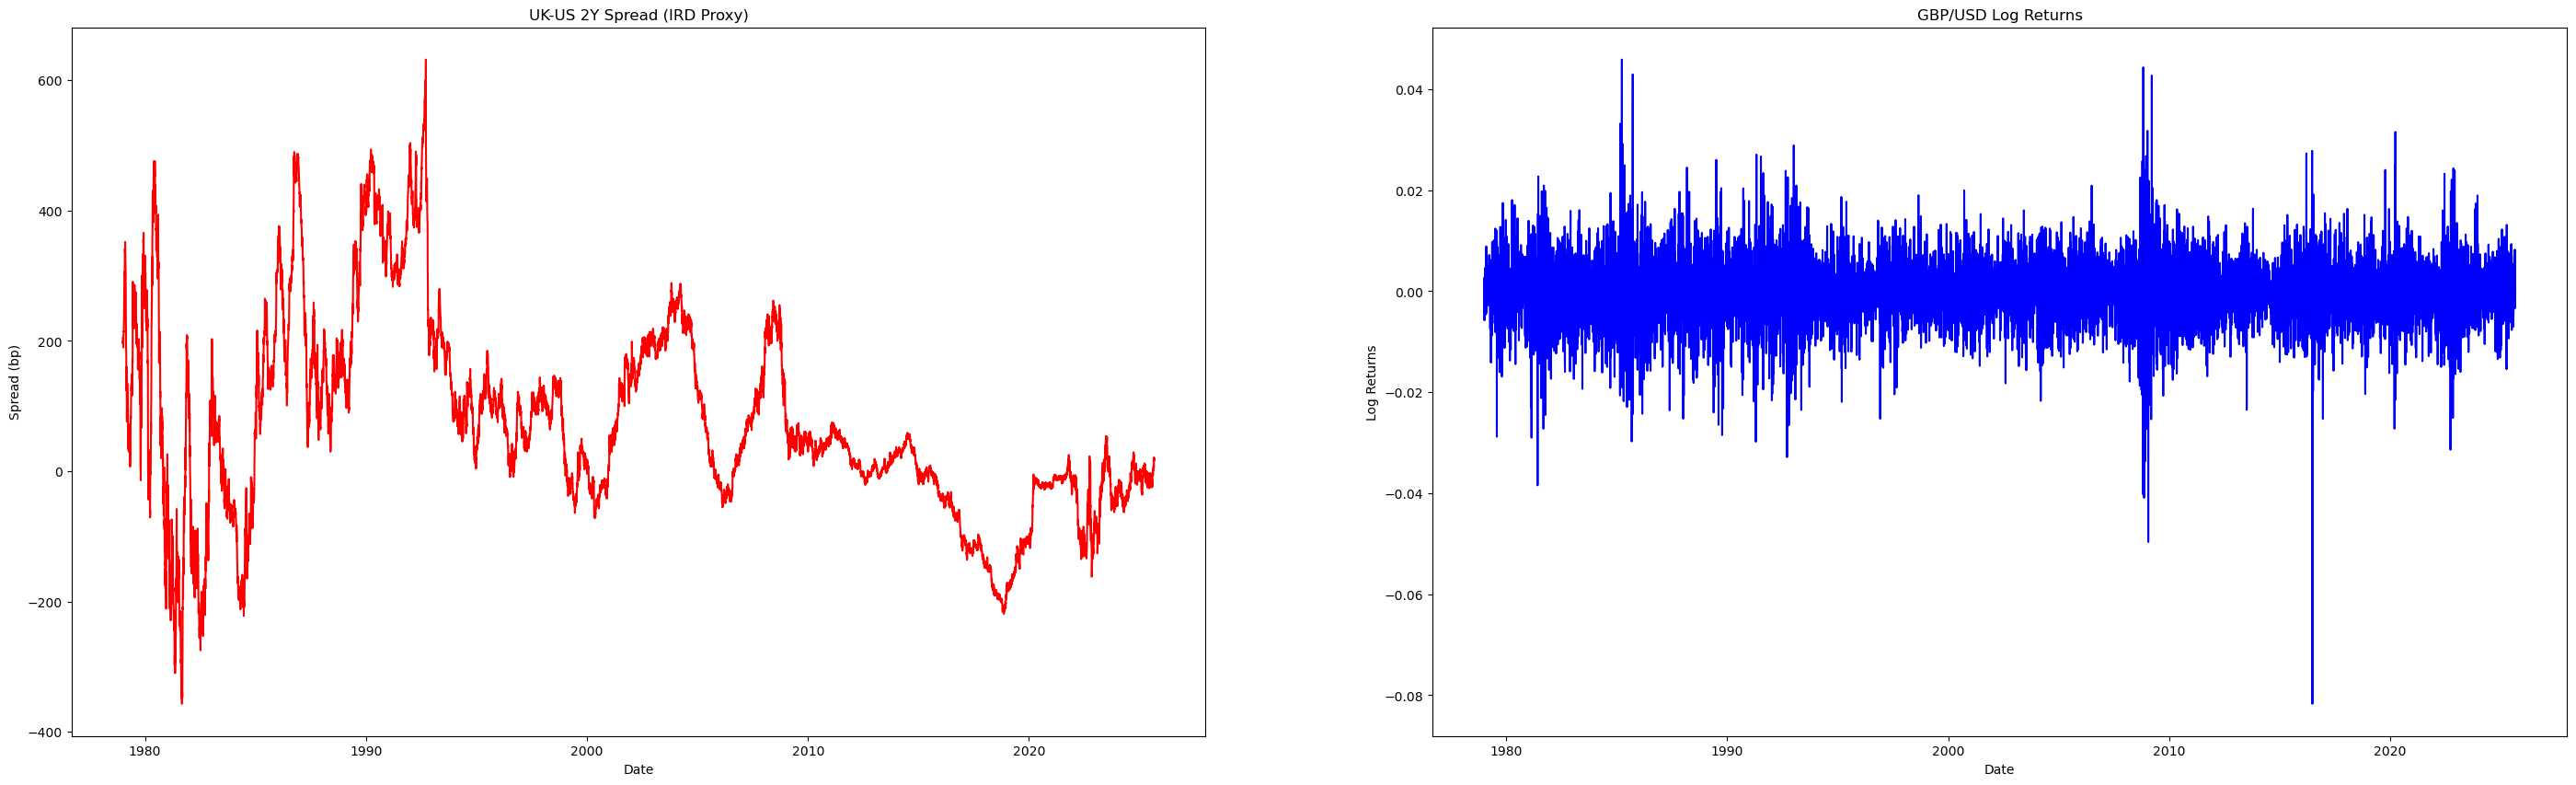

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(35, 10))

axs[0].set_title("UK-US 2Y Spread (IRD Proxy)", fontsize=12)
axs[0].plot(spread["spread_bp"], color="red")

axs[0].set_xlabel("Date")
axs[0].set_ylabel("Spread (bp)")

axs[1].set_title("GBP/USD Log Returns", fontsize=12)
axs[1].plot(gbpusd["log_return"], color="blue")

axs[1].set_xlabel("Date")
axs[1].set_ylabel("Log Returns")

### Correlation

Text(0, 0.5, 'Correlation')

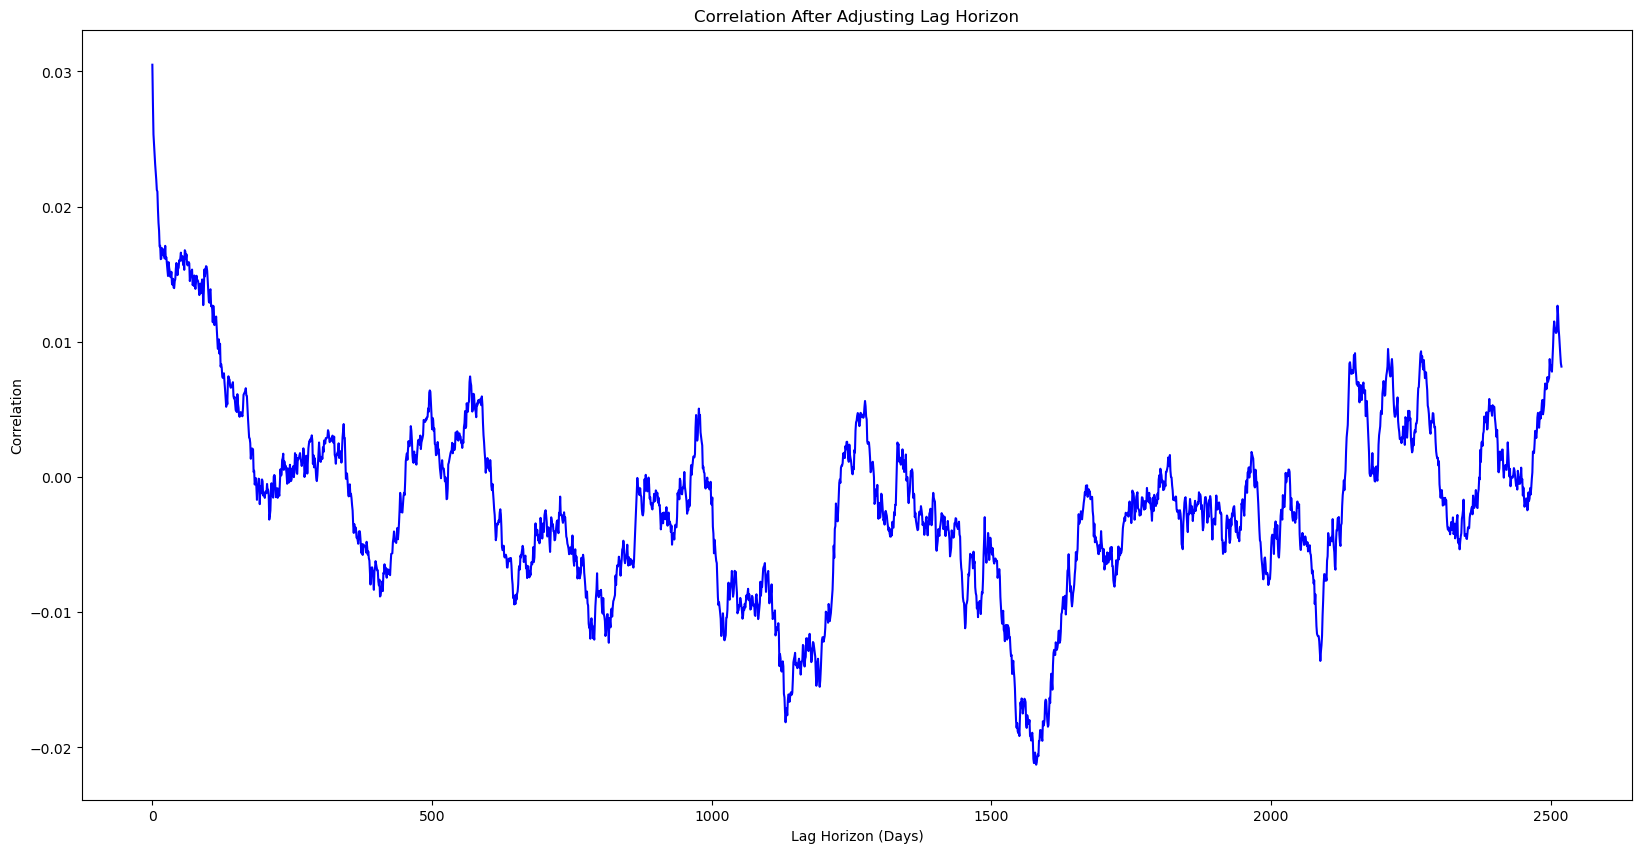

In [11]:
correlation_varying_lag_time_horizon = pd.Series(
    {h: spread["spread_bp"].shift(h).corr(gbpusd["log_return"]) for h in range(0, 252 * 10)}
)

fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("Correlation After Adjusting Lag Horizon", fontsize=12)
axs.plot(correlation_varying_lag_time_horizon, color="blue")

axs.set_xlabel("Lag Horizon (Days)")
axs.set_ylabel("Correlation")

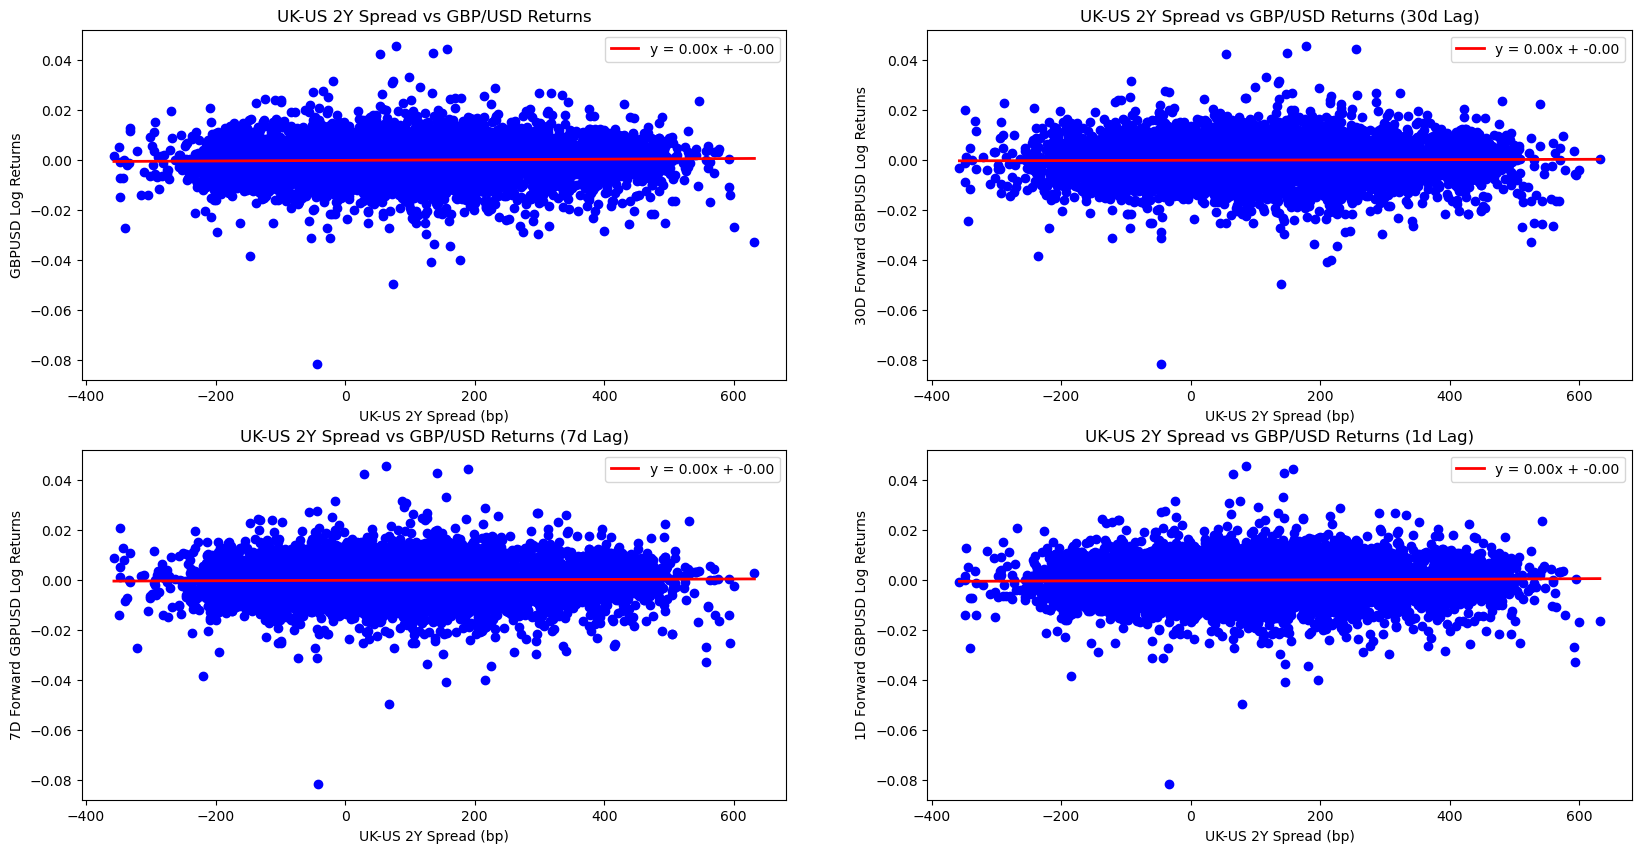

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10))

# Spread vs Returns
axs[0, 0].set_title("UK-US 2Y Spread vs GBP/USD Returns", fontsize=12)
axs[0, 0].scatter(spread["spread_bp"], gbpusd["log_return"], color="blue")

axs[0, 0].set_xlabel("UK-US 2Y Spread (bp)")
axs[0, 0].set_ylabel("GBPUSD Log Returns")

slope, intercept = np.polyfit(spread["spread_bp"], gbpusd["log_return"], 1)
x_line = np.linspace(min(spread["spread_bp"]), max(spread["spread_bp"]), 100)
y_line = slope * x_line + intercept
axs[0, 0].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")

axs[0, 0].legend()

# Spread vs 30d Forward Returns
axs[0, 1].set_title("UK-US 2Y Spread vs GBP/USD Returns (30d Lag)", fontsize=12)
axs[0, 1].scatter(spread["30d_lagged_spread_bp"][spread["30d_lagged_spread_bp"].notna()], gbpusd["log_return"][spread["30d_lagged_spread_bp"].notna()], color="blue")

axs[0, 1].set_xlabel("UK-US 2Y Spread (bp)")
axs[0, 1].set_ylabel("30D Forward GBPUSD Log Returns")

slope, intercept = np.polyfit(spread["30d_lagged_spread_bp"][spread["30d_lagged_spread_bp"].notna()], gbpusd["log_return"][spread["30d_lagged_spread_bp"].notna()], 1)
x_line = np.linspace(min(spread["30d_lagged_spread_bp"][spread["30d_lagged_spread_bp"].notna()]), max(spread["30d_lagged_spread_bp"][spread["30d_lagged_spread_bp"].notna()]), 100)
y_line = slope * x_line + intercept
axs[0, 1].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")

axs[0, 1].legend()

# Spread vs 7d Forward Returns
axs[1, 0].set_title("UK-US 2Y Spread vs GBP/USD Returns (7d Lag)", fontsize=12)
axs[1, 0].scatter(spread["7d_lagged_spread_bp"][spread["7d_lagged_spread_bp"].notna()], gbpusd["log_return"][spread["7d_lagged_spread_bp"].notna()], color="blue")

axs[1, 0].set_xlabel("UK-US 2Y Spread (bp)")
axs[1, 0].set_ylabel("7D Forward GBPUSD Log Returns")

slope, intercept = np.polyfit(spread["7d_lagged_spread_bp"][spread["7d_lagged_spread_bp"].notna()], gbpusd["log_return"][spread["7d_lagged_spread_bp"].notna()], 1)
x_line = np.linspace(min(spread["7d_lagged_spread_bp"][spread["7d_lagged_spread_bp"].notna()]), max(spread["7d_lagged_spread_bp"][spread["7d_lagged_spread_bp"].notna()]), 100)
y_line = slope * x_line + intercept
axs[1, 0].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")

axs[1, 0].legend()

# Spread vs 1d Forward Returns
axs[1, 1].set_title("UK-US 2Y Spread vs GBP/USD Returns (1d Lag)", fontsize=12)
axs[1, 1].scatter(spread["1d_lagged_spread_bp"][spread["1d_lagged_spread_bp"].notna()], gbpusd["log_return"][spread["1d_lagged_spread_bp"].notna()], color="blue")

axs[1, 1].set_xlabel("UK-US 2Y Spread (bp)")
axs[1, 1].set_ylabel("1D Forward GBPUSD Log Returns")

slope, intercept = np.polyfit(spread["1d_lagged_spread_bp"][spread["1d_lagged_spread_bp"].notna()], gbpusd["log_return"][spread["1d_lagged_spread_bp"].notna()], 1)
x_line = np.linspace(min(spread["1d_lagged_spread_bp"][spread["1d_lagged_spread_bp"].notna()]), max(spread["1d_lagged_spread_bp"][spread["1d_lagged_spread_bp"].notna()]), 100)
y_line = slope * x_line + intercept
axs[1, 1].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")

axs[1, 1].legend()

### Regressions

In [13]:
X = sm.add_constant(spread["spread_bp"])
y = gbpusd["log_return"]

model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     11.33
Date:                Fri, 17 Oct 2025   Prob (F-statistic):           0.000763
Time:                        18:40:25   Log-Likelihood:                 44889.
No. Observations:               12175   AIC:                        -8.977e+04
Df Residuals:                   12173   BIC:                        -8.976e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001   6.08e-05     -1.999      0.046      -0.000   -2.35e-06
spread_bp   1.223e-06   3.63e-07      3.367      0.001    5.11e-07    1.94e-06
==============================================================================
Omnibus:                     1845.874   Durbin-Watson:                   1.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            21833.025
Skew:                          -0.337   Prob(JB):                         0.00
Kurtosis:                       9.526   Cond. No.                         185.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Analysis, Conclusion & Next Steps

- Basically I'm asking: “Does yesterday’s rate differential explain today’s tick-to-tick FX noise?”. The answer, unsurprisingly, is “not really.”
- Daily FX returns are dominated by noise — microstructure effects, flows, sentiment, liquidity conditions — none of which are directly related to slow-moving rate differentials.
- I also suspect that here may be some scale distortion as the variance of the spread decreases over time and is non-stationary.

**Next Steps**
- Try lengthening the return horizon. Compute rolling FX returns over the next 1-week, 1-month, or even 3-month periods. The longer horizon lets the slower-moving rate differential exert influence.
- Try using z-score of Uk-US 2Y as independent.


## Analysis : UK-US 2Y Spread Z-Score vs GBP/USD Z-Score

In [14]:
spread["spread_z_score"] = (spread["spread_bp"] - spread["spread_bp"].mean()) / spread["spread_bp"].std()

In [15]:
gbpusd["price_z_score"] = (gbpusd["gbp_usd_noon_rate"] - gbpusd["gbp_usd_noon_rate"].mean()) / gbpusd["gbp_usd_noon_rate"].std()

### Plots

Text(0, 0.5, 'Z-Score')

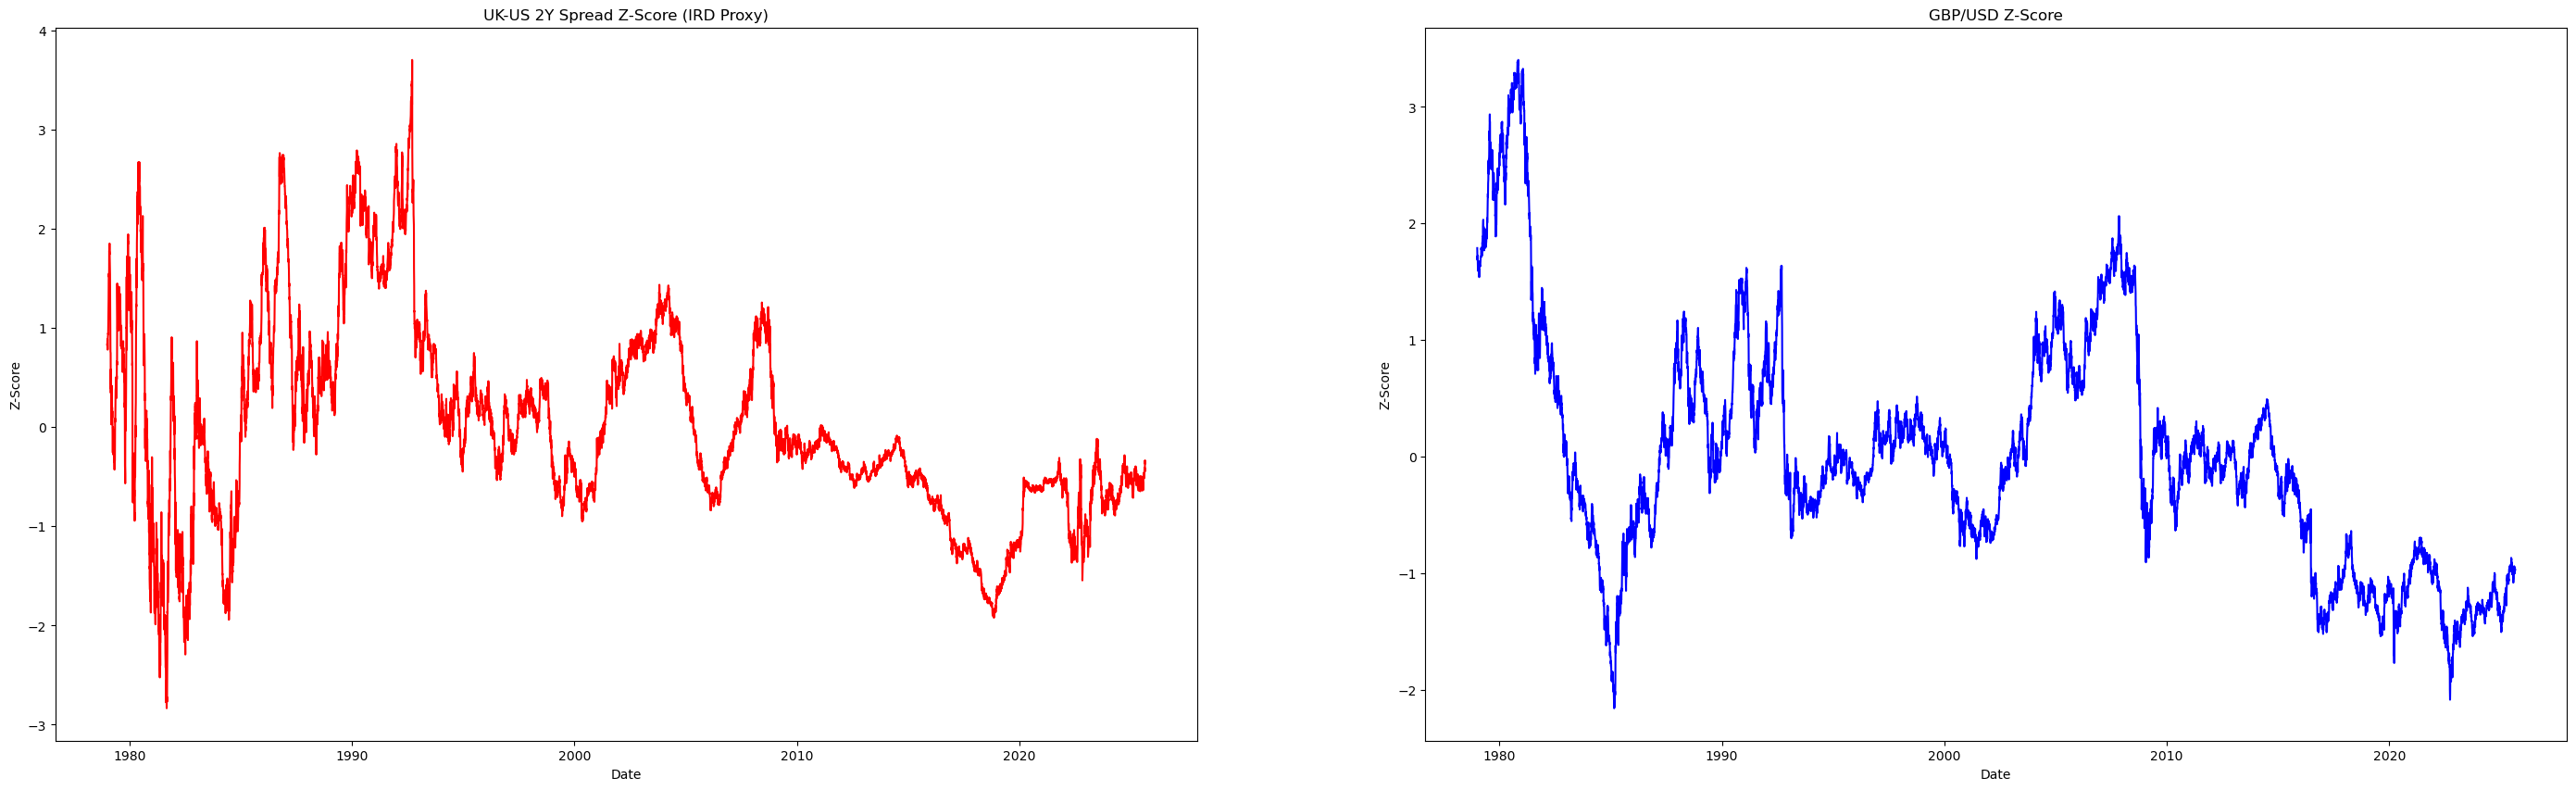

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(35, 10))

axs[0].set_title("UK-US 2Y Spread Z-Score (IRD Proxy)", fontsize=12)
axs[0].plot(spread["spread_z_score"], color="red")

axs[0].set_xlabel("Date")
axs[0].set_ylabel("Z-Score")

axs[1].set_title("GBP/USD Z-Score", fontsize=12)
axs[1].plot(gbpusd["price_z_score"], color="blue")

axs[1].set_xlabel("Date")
axs[1].set_ylabel("Z-Score")

### Correlation

Text(0, 0.5, 'Correlation')

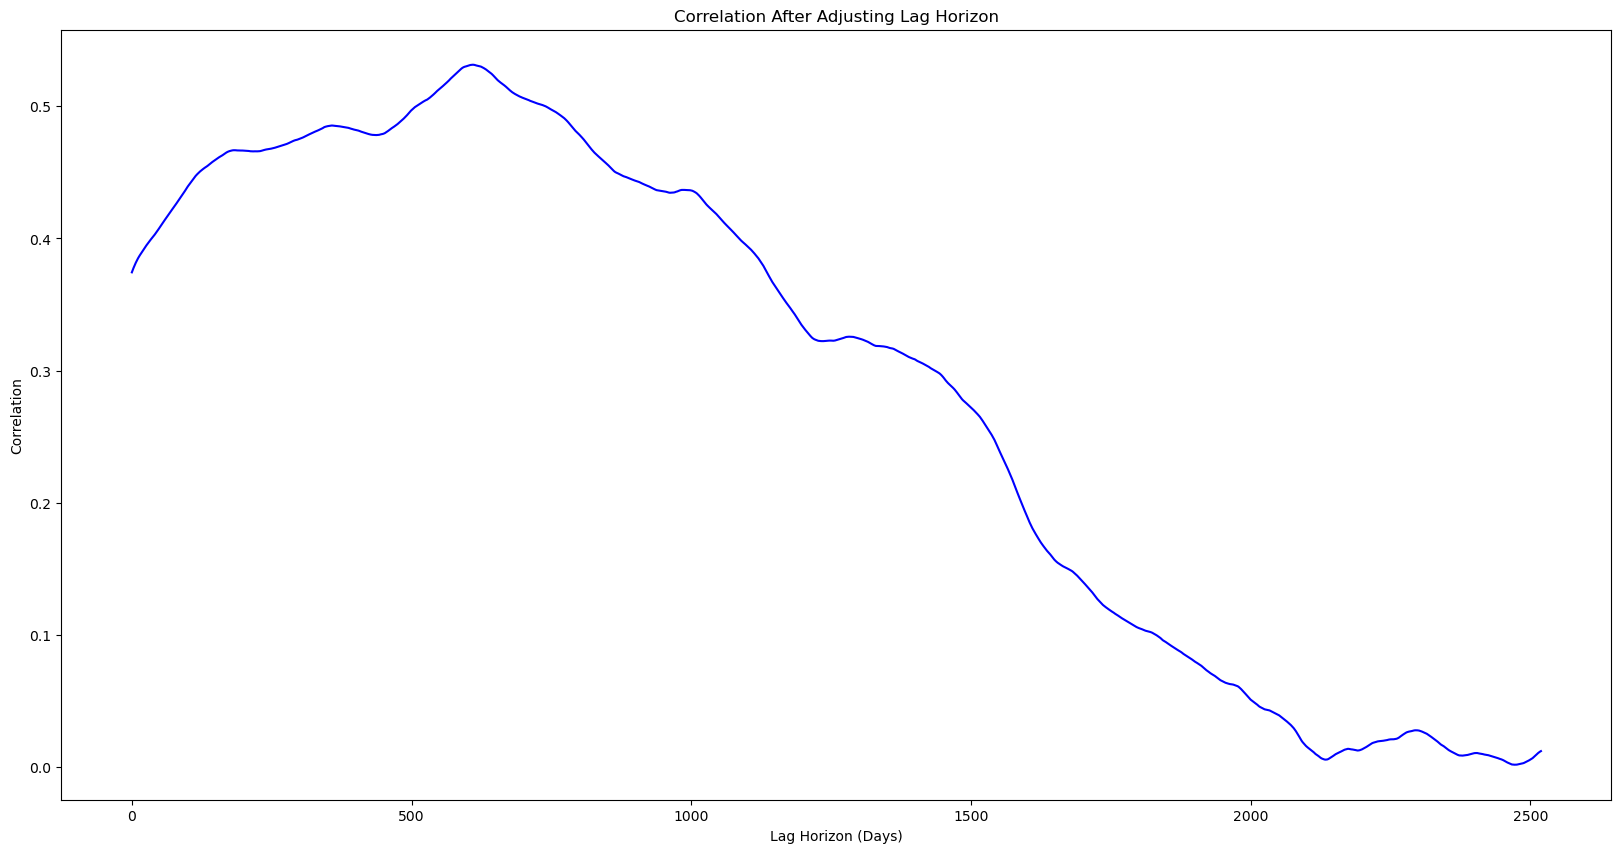

In [17]:
correlation_varying_lag_time_horizon = pd.Series(
    {h: spread["spread_z_score"].shift(h).corr(gbpusd["price_z_score"]) for h in range(0, 252 * 10)}
)

fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("Correlation After Adjusting Lag Horizon", fontsize=12)
axs.plot(correlation_varying_lag_time_horizon, color="blue")

axs.set_xlabel("Lag Horizon (Days)")
axs.set_ylabel("Correlation")

In [18]:
correlation_varying_lag_time_horizon[correlation_varying_lag_time_horizon == correlation_varying_lag_time_horizon.max()]

610    0.531385
dtype: float64

In [19]:
spread["610d_spread_z_score"] = spread["spread_z_score"].shift(610)
spread["365d_spread_z_score"] = spread["spread_z_score"].shift(365)
spread["90d_spread_z_score"] = spread["spread_z_score"].shift(90)

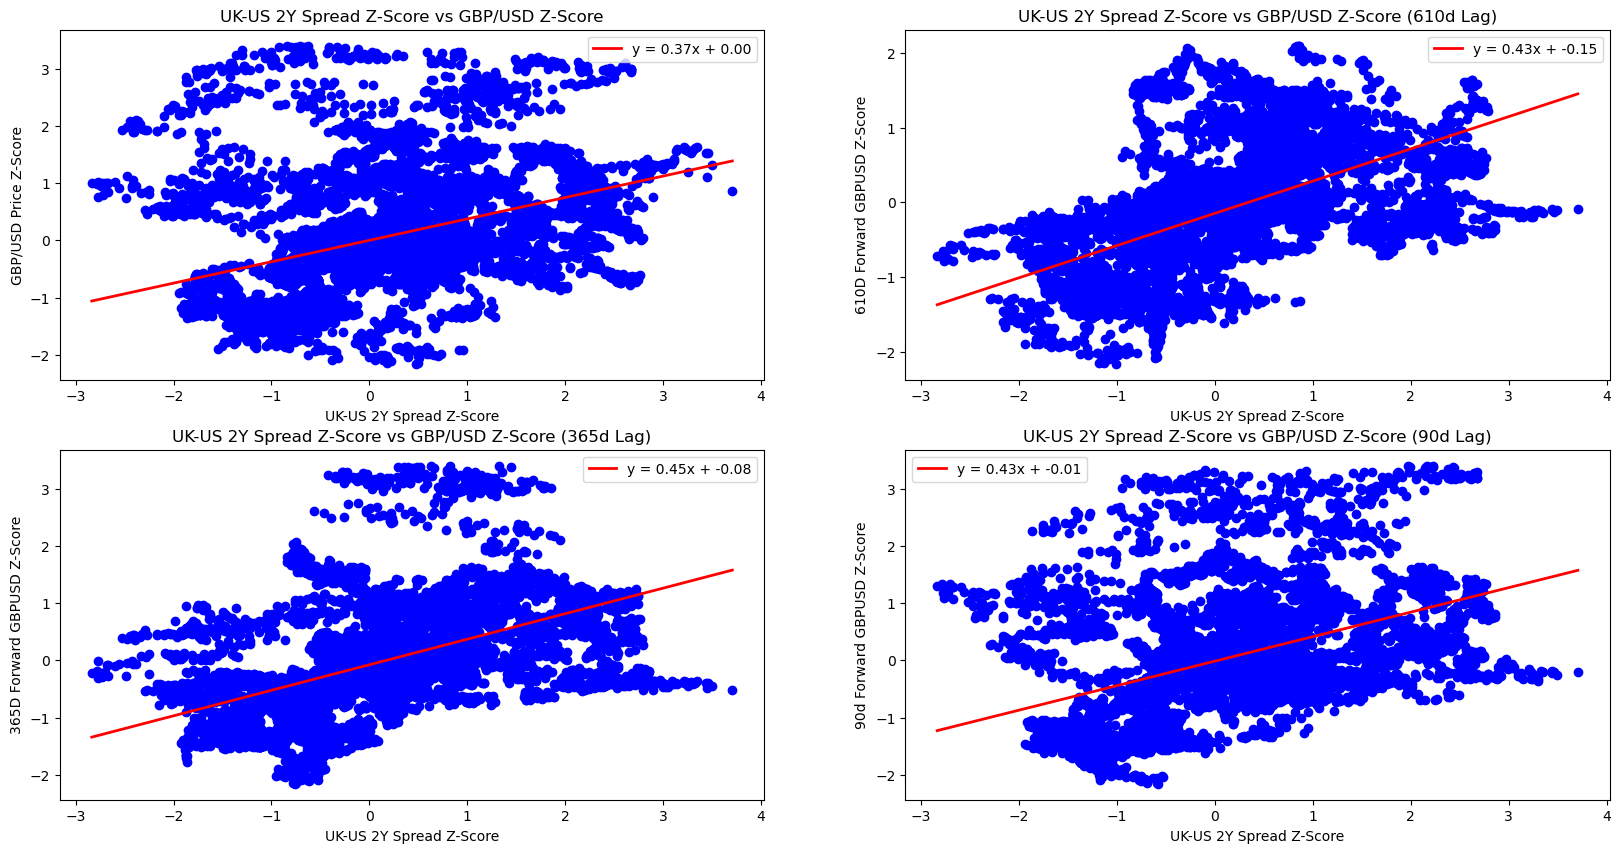

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10))

# Spread vs Returns
axs[0, 0].set_title("UK-US 2Y Spread Z-Score vs GBP/USD Z-Score", fontsize=12)
axs[0, 0].scatter(spread["spread_z_score"], gbpusd["price_z_score"], color="blue")

axs[0, 0].set_xlabel("UK-US 2Y Spread Z-Score")
axs[0, 0].set_ylabel("GBP/USD Price Z-Score")

slope, intercept = np.polyfit(spread["spread_z_score"], gbpusd["price_z_score"], 1)
x_line = np.linspace(min(spread["spread_z_score"]), max(spread["spread_z_score"]), 100)
y_line = slope * x_line + intercept
axs[0, 0].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")

axs[0, 0].legend()

# Spread vs 610d Forward Returns
axs[0, 1].set_title("UK-US 2Y Spread Z-Score vs GBP/USD Z-Score (610d Lag)", fontsize=12)
axs[0, 1].scatter(spread["610d_spread_z_score"][spread["610d_spread_z_score"].notna()], gbpusd["price_z_score"][spread["610d_spread_z_score"].notna()], color="blue")

axs[0, 1].set_xlabel("UK-US 2Y Spread Z-Score")
axs[0, 1].set_ylabel("610D Forward GBPUSD Z-Score")

slope, intercept = np.polyfit(spread["610d_spread_z_score"][spread["610d_spread_z_score"].notna()], gbpusd["price_z_score"][spread["610d_spread_z_score"].notna()], 1)
x_line = np.linspace(min(spread["610d_spread_z_score"][spread["610d_spread_z_score"].notna()]), max(spread["610d_spread_z_score"][spread["610d_spread_z_score"].notna()]), 100)
y_line = slope * x_line + intercept
axs[0, 1].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")

axs[0, 1].legend()

# Spread vs 365d Forward Returns
axs[1, 0].set_title("UK-US 2Y Spread Z-Score vs GBP/USD Z-Score (365d Lag)", fontsize=12)
axs[1, 0].scatter(spread["365d_spread_z_score"][spread["365d_spread_z_score"].notna()], gbpusd["price_z_score"][spread["365d_spread_z_score"].notna()], color="blue")

axs[1, 0].set_xlabel("UK-US 2Y Spread Z-Score")
axs[1, 0].set_ylabel("365D Forward GBPUSD Z-Score")

slope, intercept = np.polyfit(spread["365d_spread_z_score"][spread["365d_spread_z_score"].notna()], gbpusd["price_z_score"][spread["365d_spread_z_score"].notna()], 1)
x_line = np.linspace(min(spread["365d_spread_z_score"][spread["365d_spread_z_score"].notna()]), max(spread["365d_spread_z_score"][spread["365d_spread_z_score"].notna()]), 100)
y_line = slope * x_line + intercept
axs[1, 0].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")

axs[1, 0].legend()

# Spread vs 90d Forward Returns
axs[1, 1].set_title("UK-US 2Y Spread Z-Score vs GBP/USD Z-Score (90d Lag)", fontsize=12)
axs[1, 1].scatter(spread["90d_spread_z_score"][spread["90d_spread_z_score"].notna()], gbpusd["price_z_score"][spread["90d_spread_z_score"].notna()], color="blue")

axs[1, 1].set_xlabel("UK-US 2Y Spread Z-Score")
axs[1, 1].set_ylabel("90d Forward GBPUSD Z-Score")

slope, intercept = np.polyfit(spread["90d_spread_z_score"][spread["90d_spread_z_score"].notna()], gbpusd["price_z_score"][spread["90d_spread_z_score"].notna()], 1)
x_line = np.linspace(min(spread["90d_spread_z_score"][spread["90d_spread_z_score"].notna()]), max(spread["90d_spread_z_score"][spread["90d_spread_z_score"].notna()]), 100)
y_line = slope * x_line + intercept
axs[1, 1].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")

axs[1, 1].legend()

### Regressions

In [21]:
X = sm.add_constant(spread["spread_z_score"][spread["spread_z_score"].notna()])
y = gbpusd["price_z_score"][spread["spread_z_score"].notna()]

model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          price_z_score   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     1983.
Date:                Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                        18:40:28   Log-Likelihood:                -16356.
No. Observations:               12175   AIC:                         3.272e+04
Df Residuals:                   12173   BIC:                         3.273e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3.464e-16      0.008   4.12e-14      1.000      -0.016       0.016
spread_z_score     0.3743      0.008     44.535      0.000       0.358       0.391
==============================================================================
Omnibus:                     2130.068   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3986.499
Skew:                           1.091   Prob(JB):                         0.00
Kurtosis:                       4.759   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
X = sm.add_constant(spread["610d_spread_z_score"][spread["610d_spread_z_score"].notna()])
y = gbpusd["price_z_score"][spread["610d_spread_z_score"].notna()]

model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          price_z_score   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                     4550.
Date:                Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                        18:40:28   Log-Likelihood:                -12253.
No. Observations:               11565   AIC:                         2.451e+04
Df Residuals:                   11563   BIC:                         2.453e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.1474      0.006    -22.700      0.000      -0.160      -0.135
610d_spread_z_score     0.4309      0.006     67.452      0.000       0.418       0.443
==============================================================================
Omnibus:                      334.286   Durbin-Watson:                   0.004
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              365.779
Skew:                           0.416   Prob(JB):                     3.73e-80
Kurtosis:                       3.260   Cond. No.                         1.03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [23]:
X = sm.add_constant(spread["365d_spread_z_score"][spread["365d_spread_z_score"].notna()])
y = gbpusd["price_z_score"][spread["365d_spread_z_score"].notna()]

model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          price_z_score   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     3633.
Date:                Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                        18:40:28   Log-Likelihood:                -14310.
No. Observations:               11810   AIC:                         2.862e+04
Df Residuals:                   11808   BIC:                         2.864e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.0775      0.007    -10.360      0.000      -0.092      -0.063
365d_spread_z_score     0.4464      0.007     60.273      0.000       0.432       0.461
==============================================================================
Omnibus:                     2230.479   Durbin-Watson:                   0.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4809.821
Skew:                           1.102   Prob(JB):                         0.00
Kurtosis:                       5.216   Cond. No.                         1.02
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [24]:
X = sm.add_constant(spread["90d_spread_z_score"][spread["90d_spread_z_score"].notna()])
y = gbpusd["price_z_score"][spread["90d_spread_z_score"].notna()]

model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          price_z_score   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     2785.
Date:                Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                        18:40:28   Log-Likelihood:                -15799.
No. Observations:               12085   AIC:                         3.160e+04
Df Residuals:                   12083   BIC:                         3.162e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.0148      0.008     -1.817      0.069      -0.031       0.001
90d_spread_z_score     0.4283      0.008     52.769      0.000       0.412       0.444
==============================================================================
Omnibus:                     2059.322   Durbin-Watson:                   0.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3512.307
Skew:                           1.121   Prob(JB):                         0.00
Kurtosis:                       4.397   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Analysis & Next Steps

**Limitations**
- Spurious Correlation: Two non-stationary distributions
- Global Z-Scores (not rolling)

**Conclusion**
- Shows there might be something so worth investigating but is no means a signal of reliable predictability


**Next Steps**
- X


## Overview Plots

### UK 2Y vs US 2Y Time-Series

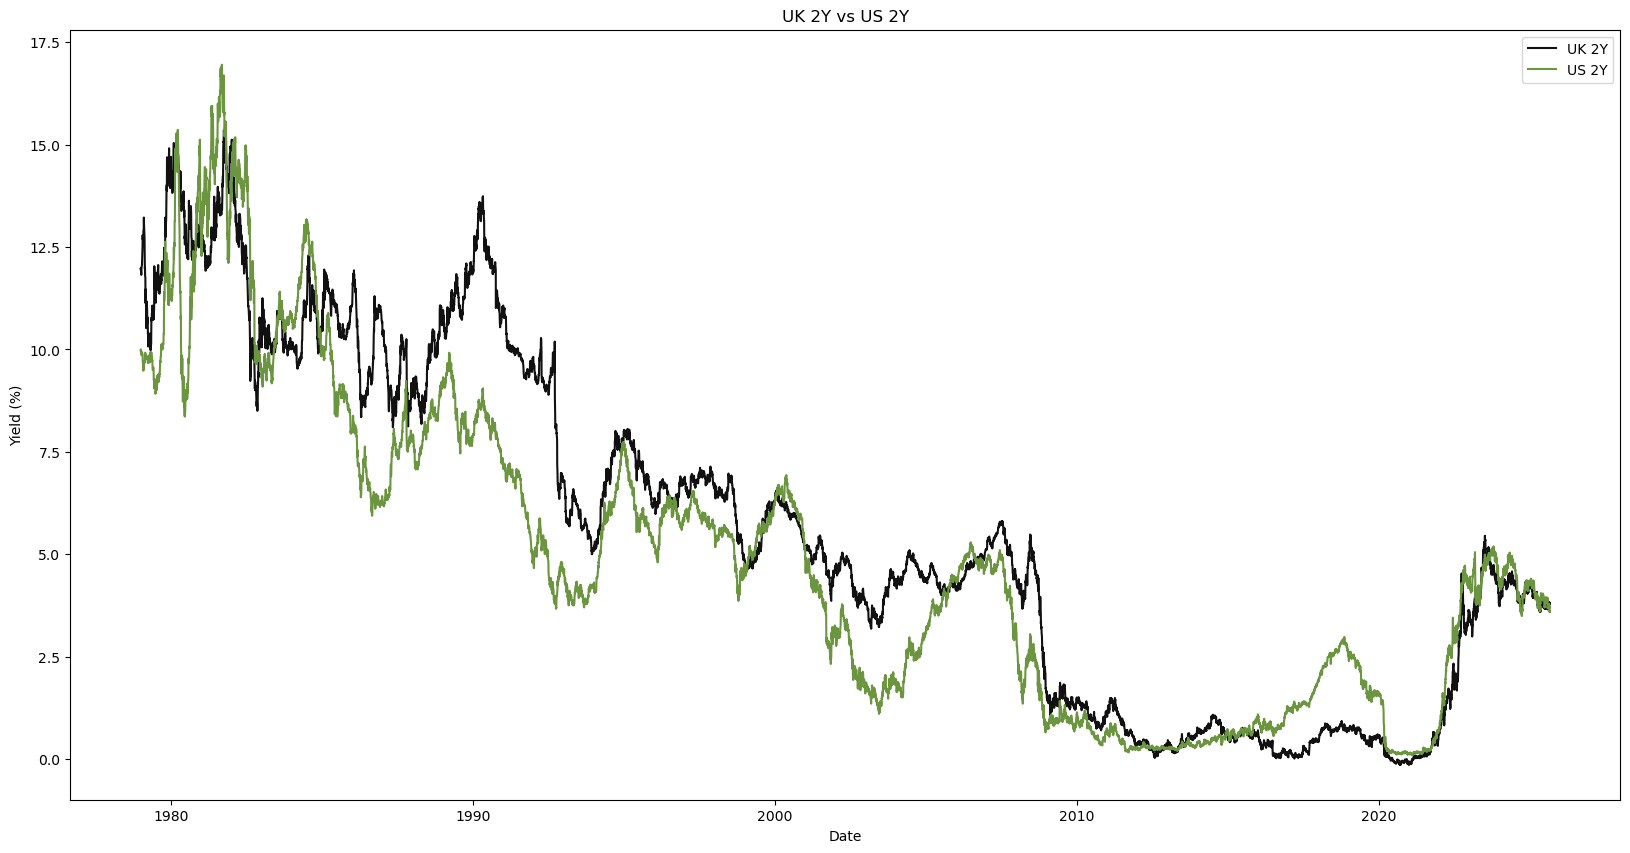

In [51]:
fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("UK 2Y vs US 2Y", fontsize=12)
axs.plot(spread["uk_2y"], label="UK 2Y", color="#111111")
axs.plot(spread["us_2y"], label="US 2Y", color="#6B953F")

axs.set_xlabel("Date")
axs.set_ylabel("Yield (%)")
axs.legend()

### UK-US 2Y Spread (IRD Proxy)

Text(0, 0.5, 'Z-Score')

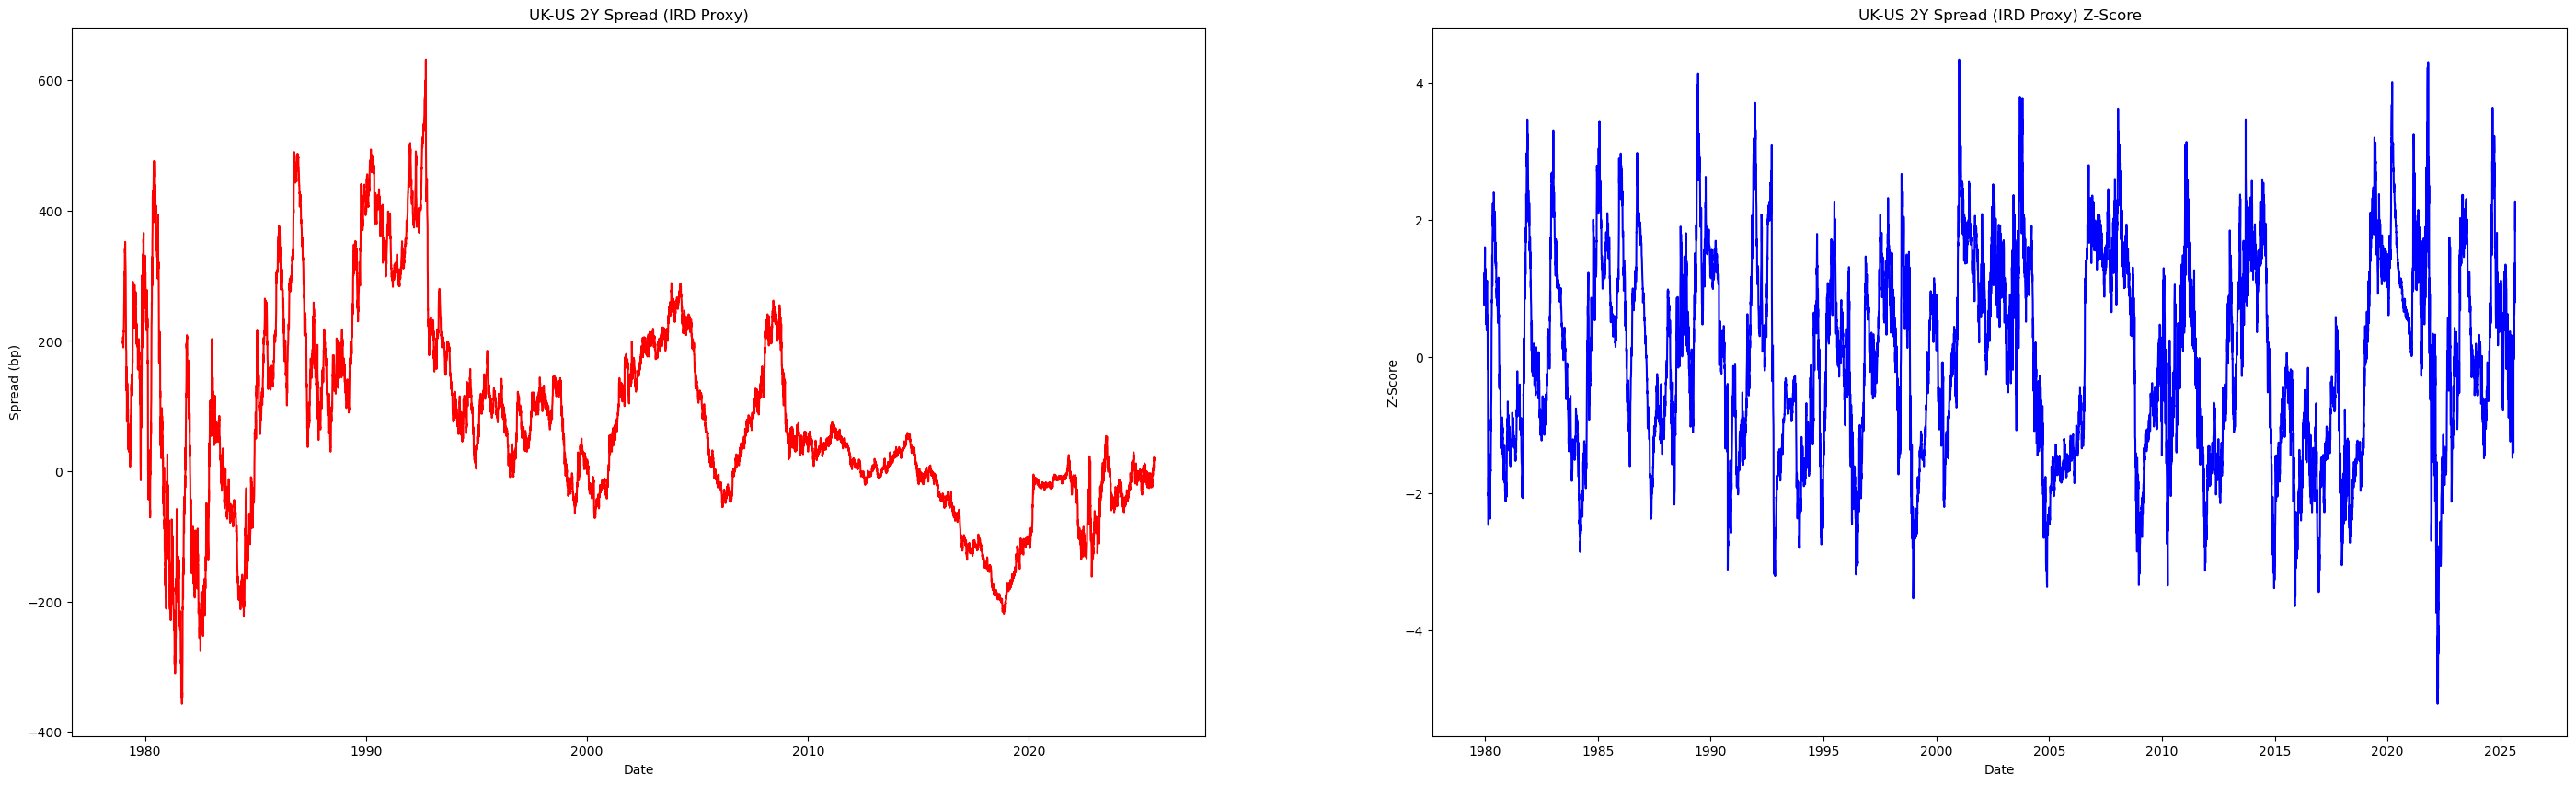

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(35, 10))

axs[0].set_title("UK-US 2Y Spread (IRD Proxy)", fontsize=12)
axs[0].plot(spread["spread_bp"], label="IRD (UK/US 2Y Spread)", color="red")

axs[0].set_xlabel("Date")
axs[0].set_ylabel("Spread (bp)")

axs[1].set_title("UK-US 2Y Spread (IRD Proxy) Z-Score", fontsize=12)
axs[1].plot(spread["spread_bp_z_score"], color="blue")

axs[1].set_xlabel("Date")
axs[1].set_ylabel("Z-Score")

### GBP/USD Price

Text(0, 0.5, 'Log Price')

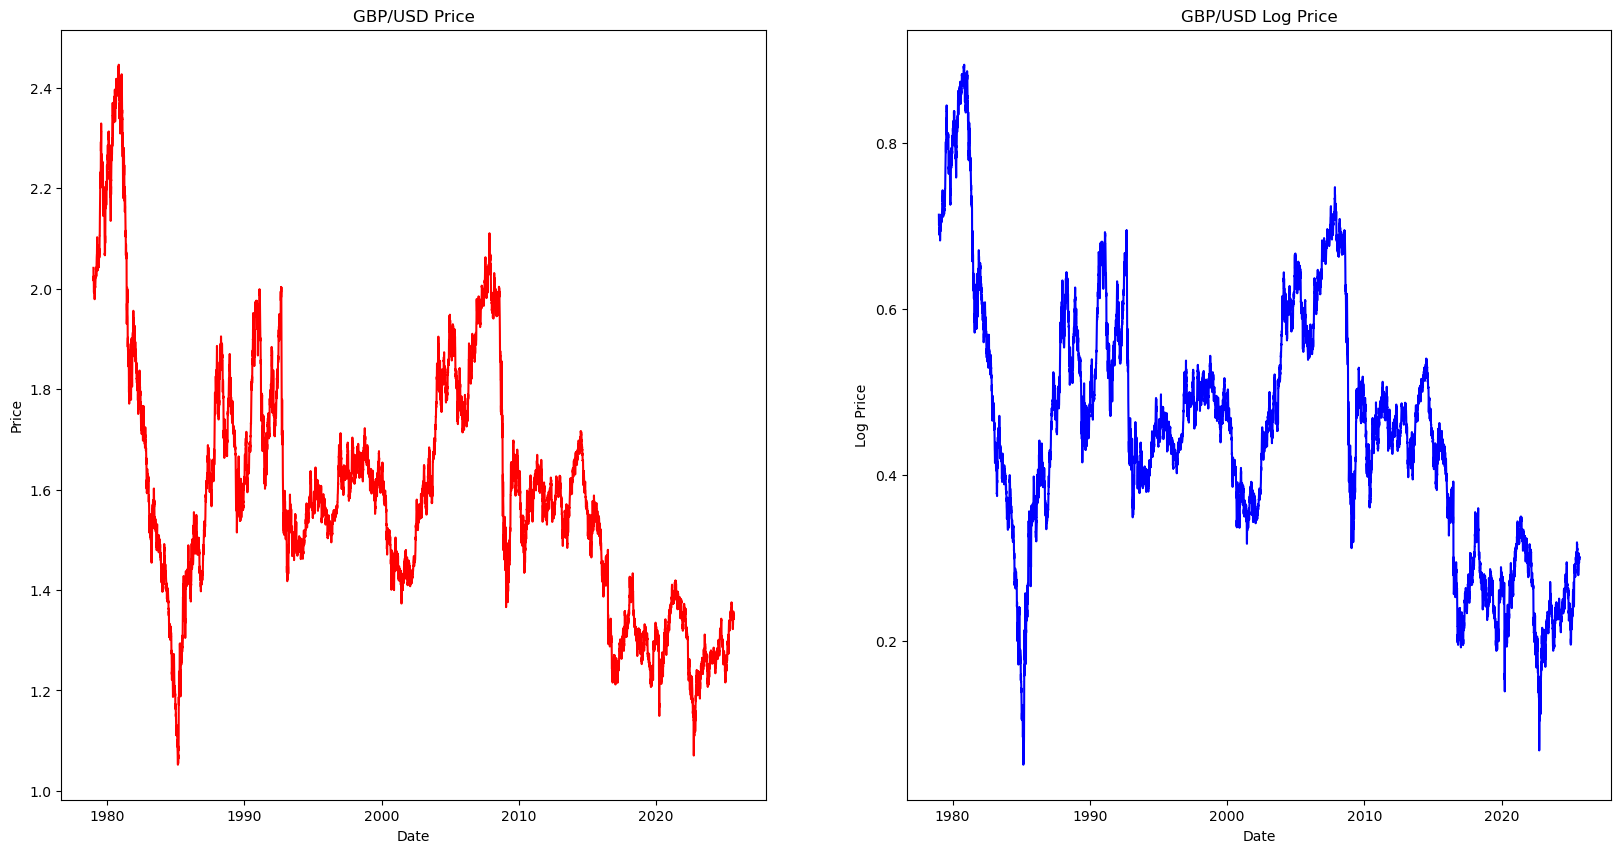

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))

axs[0].set_title("GBP/USD Price", fontsize=12)
axs[0].plot(gbpusd["gbp_usd_noon_rate"], color="red")

axs[0].set_xlabel("Date")
axs[0].set_ylabel("Price")

axs[1].set_title("GBP/USD Log Price", fontsize=12)
axs[1].plot(np.log(gbpusd["gbp_usd_noon_rate"]), color="blue")

axs[1].set_xlabel("Date")
axs[1].set_ylabel("Log Price")

### UK-US 2Y Spread (IRD Proxy) Daily Change

Text(0, 0.5, 'Z-Score')

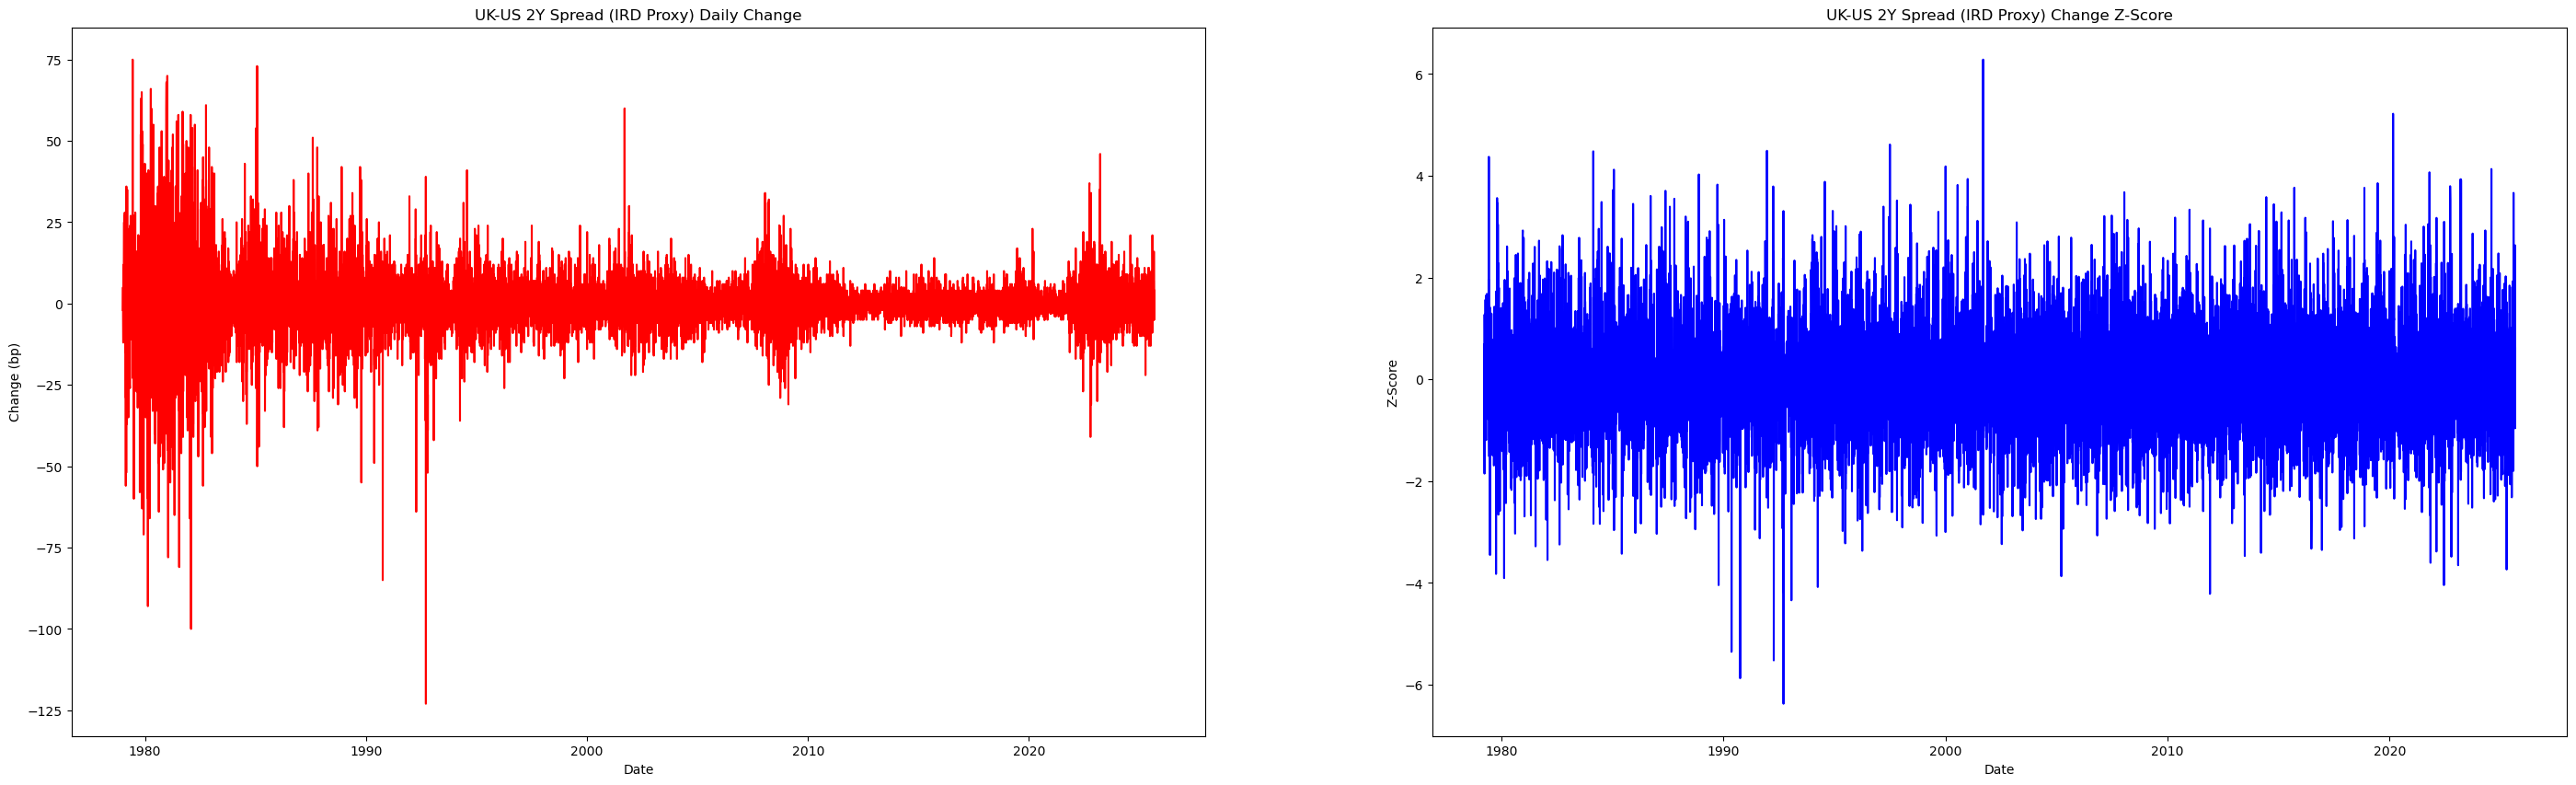

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(35, 10))

axs[0].set_title("UK-US 2Y Spread (IRD Proxy) Daily Change", fontsize=12)
axs[0].plot(spread["spread_abs_change_daily"], color="red")

axs[0].set_xlabel("Date")
axs[0].set_ylabel("Change (bp)")

axs[1].set_title("UK-US 2Y Spread (IRD Proxy) Change Z-Score", fontsize=12)
axs[1].plot(spread["spread_abs_change_daily_z_score"], color="blue")

axs[1].set_xlabel("Date")
axs[1].set_ylabel("Z-Score")

### UK-US 2Y Spread (IRD Proxy) Change Z-Score

/tmp/ipykernel_4838/1230784232.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs.legend()


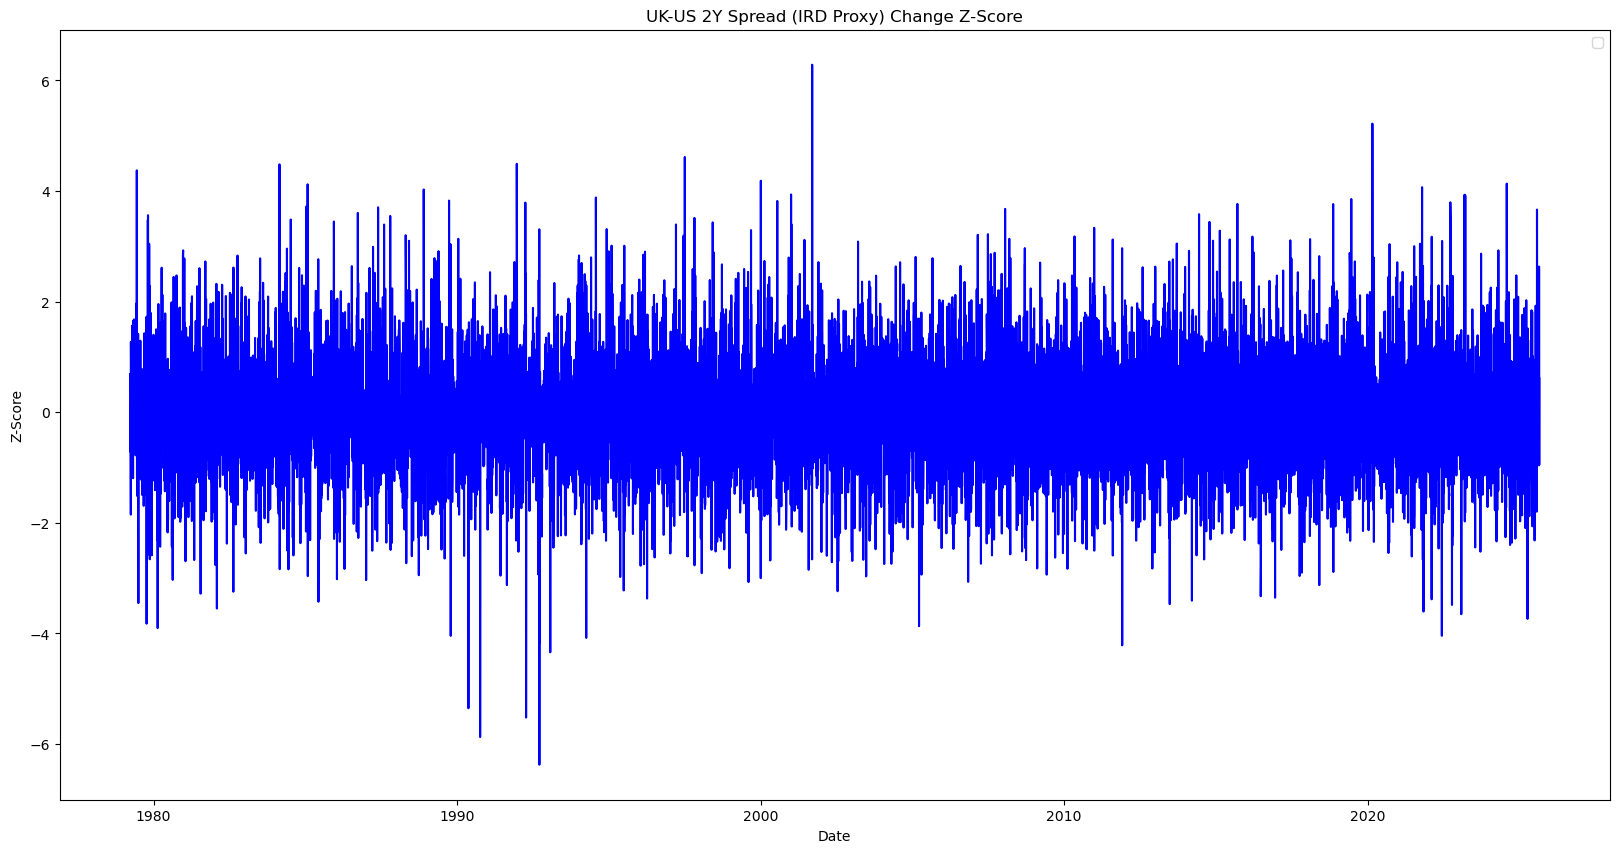

In [29]:
fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("UK-US 2Y Spread (IRD Proxy) Change Z-Score", fontsize=12)
axs.plot(spread["spread_abs_change_daily_z_score"], color="blue")

axs.set_xlabel("Date")
axs.set_ylabel("Z-Score")
axs.legend()

### GBP/USD Returns

/tmp/ipykernel_4838/1398455200.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs.legend()


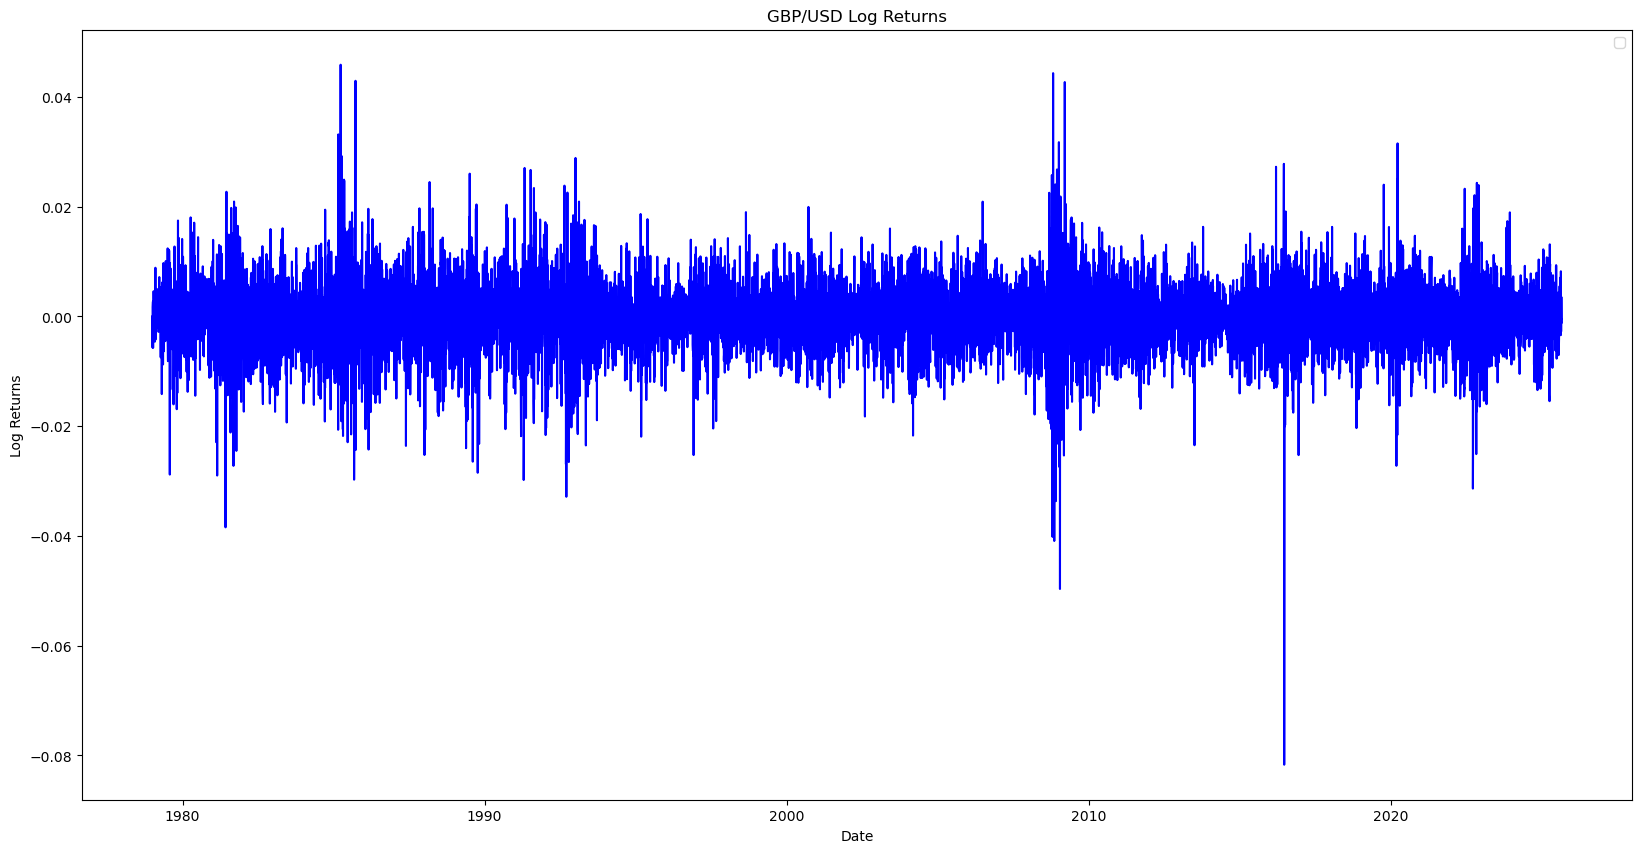

In [30]:
fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("GBP/USD Log Returns", fontsize=12)
axs.plot(gbpusd["log_return"], color="blue")

""" # Mark GFC
start = pd.Timestamp("2007-01-01")
end = pd.Timestamp("2009-01-01")
axs.axvspan(start, end, color="red", alpha=0.3, label="GFC")

# Mark COVID
start = pd.Timestamp("2020-01-01")
end = pd.Timestamp("2021-01-01")
axs.axvspan(start, end, color="green", alpha=0.3, label="COVID")

# Mark Truss Scandal
start = pd.Timestamp("2022-06-01")
end = pd.Timestamp("2023-01-01")
axs.axvspan(start, end, color="blue", alpha=0.3, label="Truss Scandal") """

axs.set_xlabel("Date")
axs.set_ylabel("Log Returns")
axs.legend()

## Spread vs GBP/USD Time-Series Overlay

### **Global Z-Score**

### Standardization

In [31]:
gbpusd_zscore = (gbpusd["gbp_usd_noon_rate"] - gbpusd["gbp_usd_noon_rate"].mean()) / gbpusd["gbp_usd_noon_rate"].std()
spread_zscore = (spread["spread_bp"] - spread["spread_bp"].mean()) / spread["spread_bp"].std()

### Plot

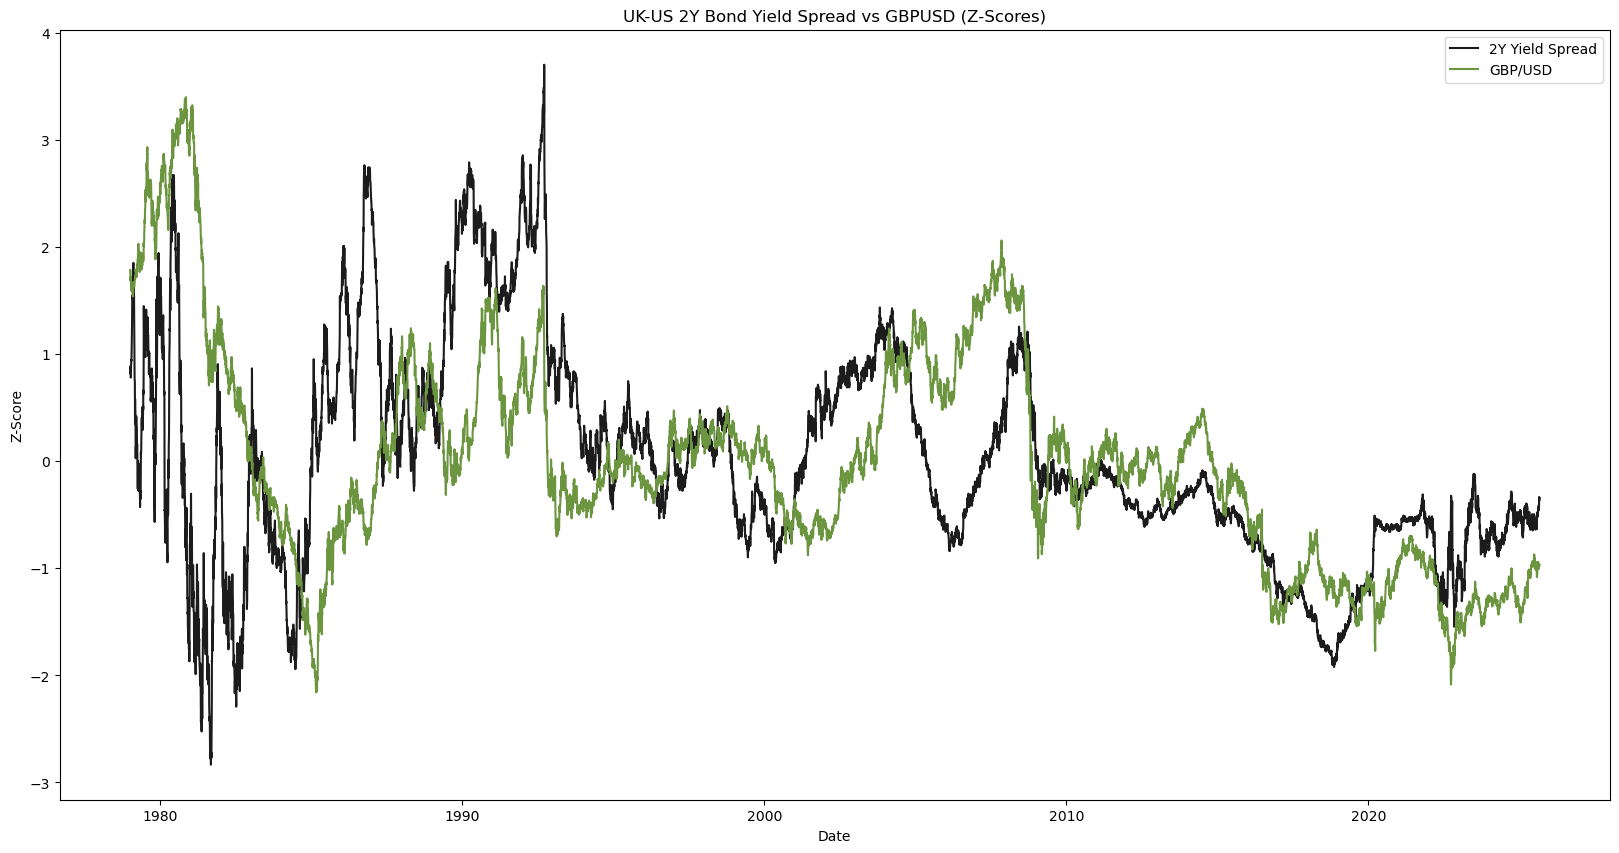

In [32]:
fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("UK-US 2Y Bond Yield Spread vs GBPUSD (Z-Scores)", fontsize=12)
axs.plot(spread_zscore, label="2Y Yield Spread", color="#1C1C1C")
axs.plot(gbpusd_zscore, label="GBP/USD", color="#6B953F")

""" # Mark GFC
start = pd.Timestamp("2007-01-01")
end = pd.Timestamp("2009-01-01")
axs.axvspan(start, end, color="red", alpha=0.3, label="GFC")

# Mark COVID
start = pd.Timestamp("2020-01-01")
end = pd.Timestamp("2021-01-01")
axs.axvspan(start, end, color="green", alpha=0.3, label="COVID") """

axs.set_xlabel("Date")
axs.set_ylabel("Z-Score")
axs.legend()

### Analysis

- Early signs of correlation and co-movement. Definitely related.

### **Rolling Z-Score**

### Standardization

In [33]:
window = 252 * 3
gbpusd_rolling_zscore = (gbpusd["gbp_usd_noon_rate"] - gbpusd["gbp_usd_noon_rate"].rolling(window).mean()) / gbpusd["gbp_usd_noon_rate"].rolling(window).std()
spread_rolling_zscore = (spread["spread_bp"] - spread["spread_bp"].rolling(window).mean()) / spread["spread_bp"].rolling(window).std()


### Plot

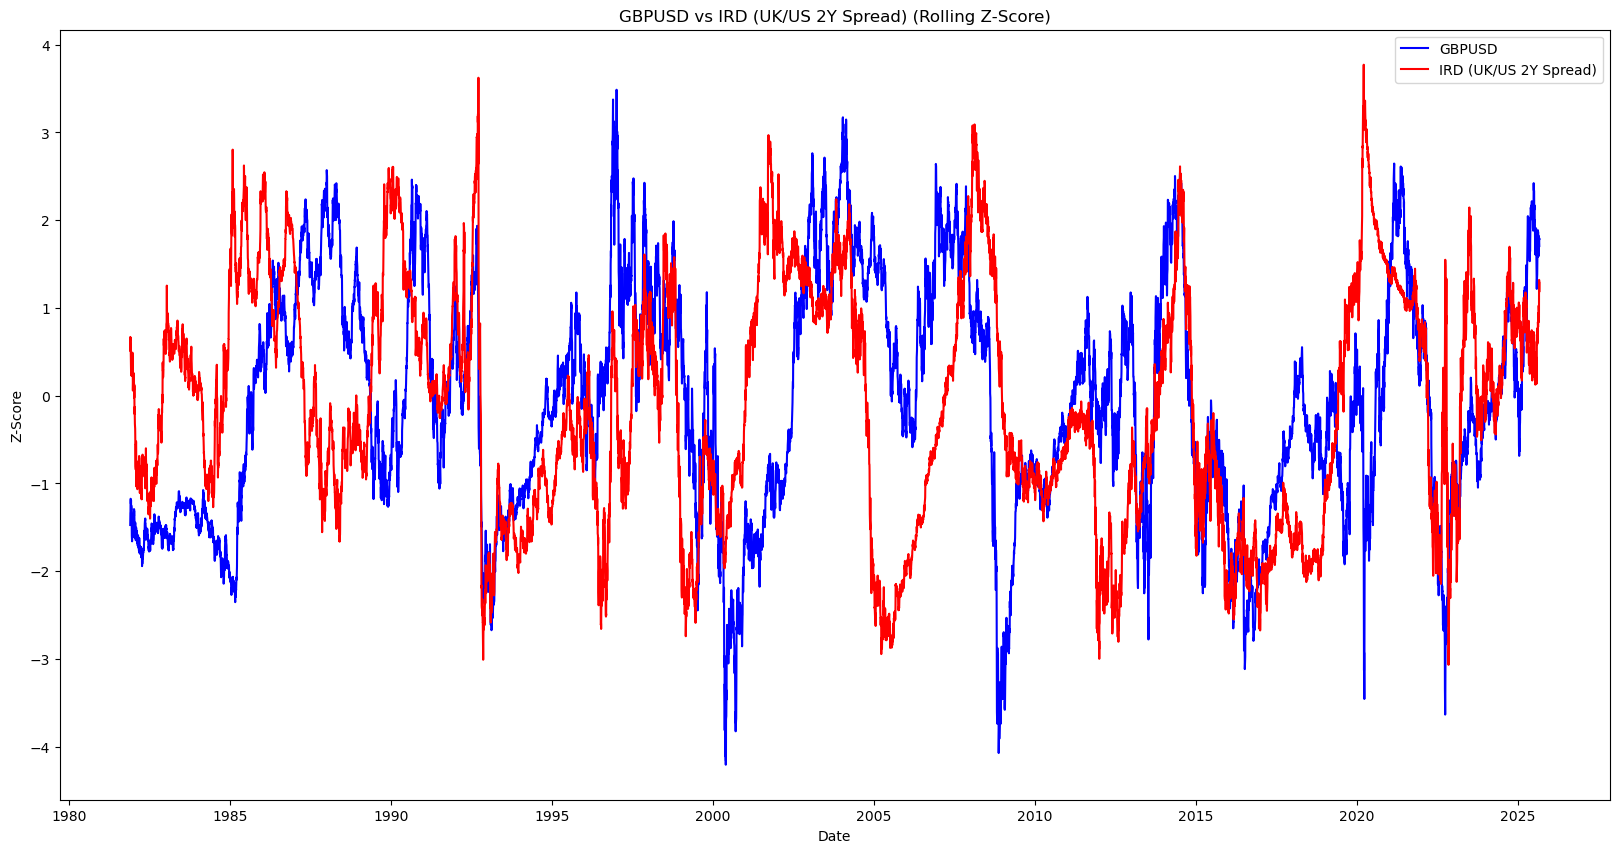

In [34]:
fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("GBPUSD vs IRD (UK/US 2Y Spread) (Rolling Z-Score)", fontsize=12)
axs.plot(gbpusd_rolling_zscore, label="GBPUSD", color="blue")
axs.plot(spread_rolling_zscore, label="IRD (UK/US 2Y Spread)", color="red")

axs.set_xlabel("Date")
axs.set_ylabel("Z-Score")
axs.legend()

## Spread Change vs GBP/USD Returns Scatter Plot

### Plot

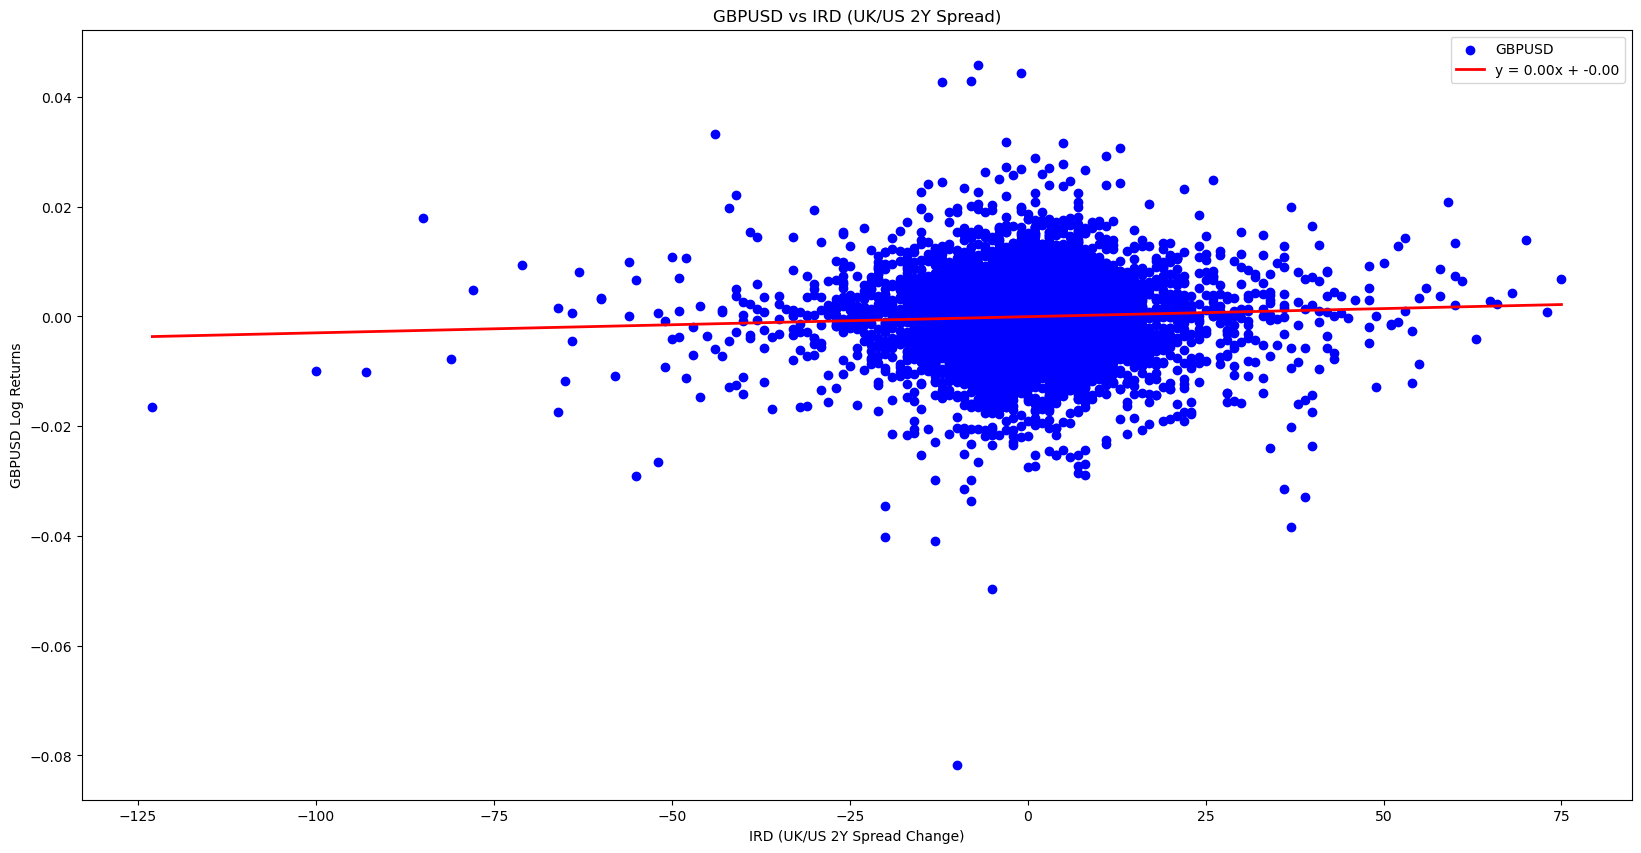

In [35]:
fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("GBPUSD vs IRD (UK/US 2Y Spread)", fontsize=12)
axs.scatter(spread["spread_abs_change_daily"], gbpusd["log_return"], label="GBPUSD", color="blue")

slope, intercept = np.polyfit(spread["spread_abs_change_daily"].iloc[1:-1], gbpusd["log_return"].iloc[1:-1], 1)
x_line = np.linspace(min(spread["spread_abs_change_daily"].iloc[1:-1]), max(spread["spread_abs_change_daily"].iloc[1:-1]), 100)
y_line = slope * x_line + intercept
axs.plot(x_line, y_line, color="red", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")

axs.set_xlabel("IRD (UK/US 2Y Spread Change)")
axs.set_ylabel("GBPUSD Log Returns")
axs.legend()

### Plot Against Forward Returns

Text(0, 0.5, 'GBP/USD 30D Forward Log Returns')

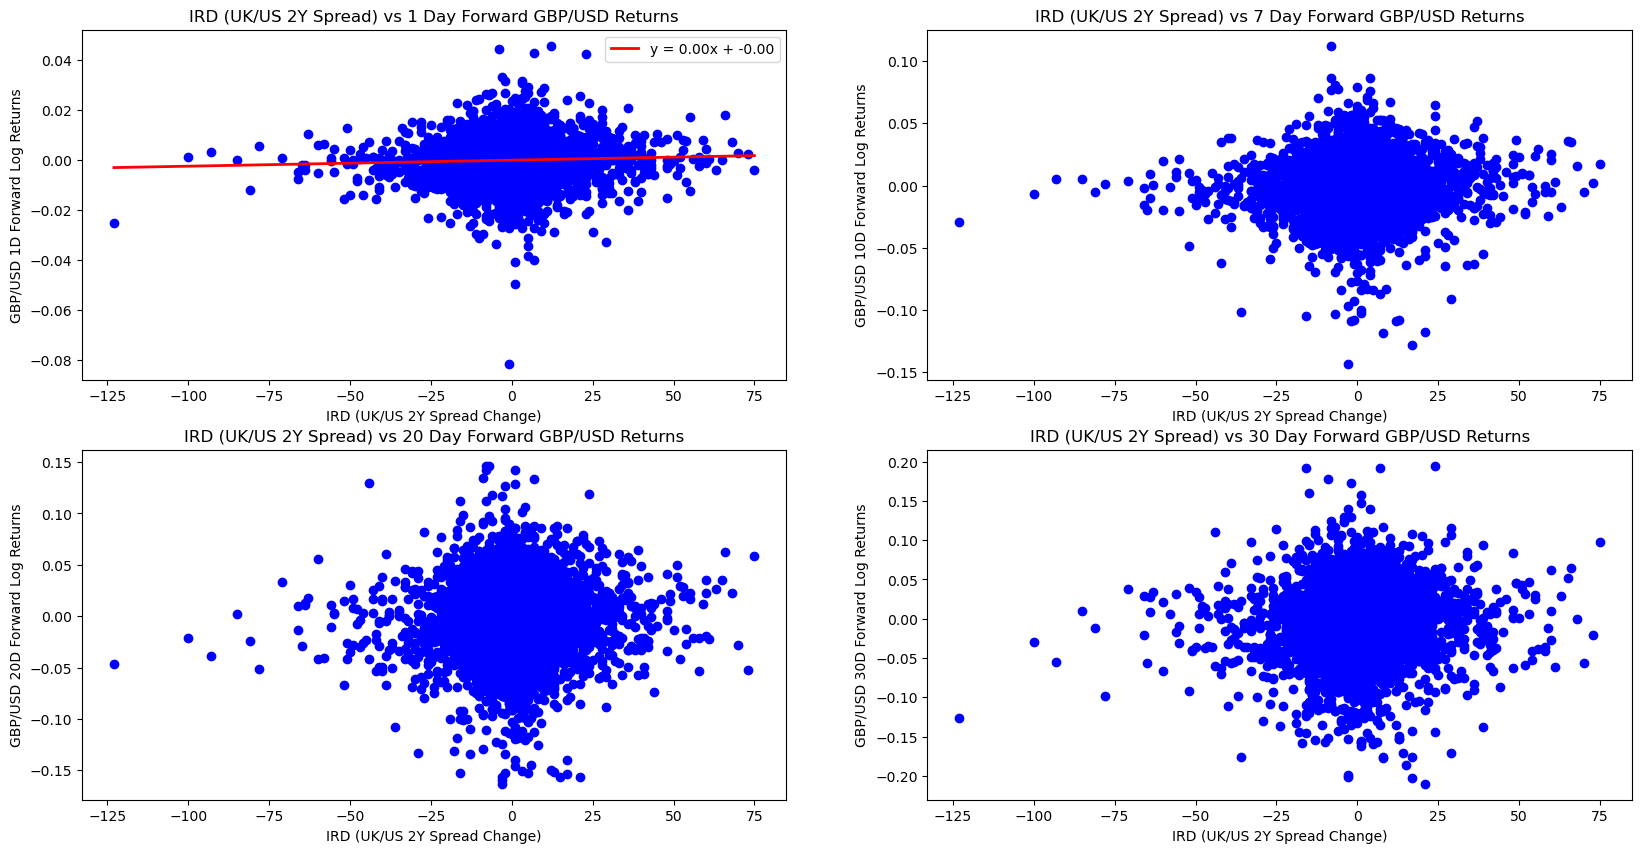

In [36]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10))

axs[0, 0].set_title("IRD (UK/US 2Y Spread) vs 1 Day Forward GBP/USD Returns", fontsize=12)
axs[0, 0].scatter(spread["spread_abs_change_daily"], np.log(gbpusd["gbp_usd_noon_rate"].shift(-1) / gbpusd["gbp_usd_noon_rate"]), color="blue")

axs[0, 0].set_xlabel("IRD (UK/US 2Y Spread Change)")
axs[0, 0].set_ylabel("GBP/USD 1D Forward Log Returns")

slope, intercept = np.polyfit(spread["spread_abs_change_daily"].iloc[1:-1], np.log(gbpusd["gbp_usd_noon_rate"].shift(-1) / gbpusd["gbp_usd_noon_rate"]).iloc[1:-1], 1)
x_line = np.linspace(min(spread["spread_abs_change_daily"].iloc[1:-1]), max(spread["spread_abs_change_daily"].iloc[1:-1]), 100)
y_line = slope * x_line + intercept
axs[0, 0].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")

axs[0, 0].legend()

axs[0, 1].set_title("IRD (UK/US 2Y Spread) vs 7 Day Forward GBP/USD Returns", fontsize=12)
axs[0, 1].scatter(spread["spread_abs_change_daily"], np.log(gbpusd["gbp_usd_noon_rate"].shift(-7) / gbpusd["gbp_usd_noon_rate"]), color="blue")

axs[0, 1].set_xlabel("IRD (UK/US 2Y Spread Change)")
axs[0, 1].set_ylabel("GBP/USD 10D Forward Log Returns")

axs[1, 0].set_title("IRD (UK/US 2Y Spread) vs 20 Day Forward GBP/USD Returns", fontsize=12)
axs[1, 0].scatter(spread["spread_abs_change_daily"], np.log(gbpusd["gbp_usd_noon_rate"].shift(-20) / gbpusd["gbp_usd_noon_rate"]), color="blue")

axs[1, 0].set_xlabel("IRD (UK/US 2Y Spread Change)")
axs[1, 0].set_ylabel("GBP/USD 20D Forward Log Returns")

axs[1, 1].set_title("IRD (UK/US 2Y Spread) vs 30 Day Forward GBP/USD Returns", fontsize=12)
axs[1, 1].scatter(spread["spread_abs_change_daily"], np.log(gbpusd["gbp_usd_noon_rate"].shift(-30) / gbpusd["gbp_usd_noon_rate"]), color="blue")

axs[1, 1].set_xlabel("IRD (UK/US 2Y Spread Change)")
axs[1, 1].set_ylabel("GBP/USD 30D Forward Log Returns")


/tmp/ipykernel_4838/1894853380.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0, 0].legend()


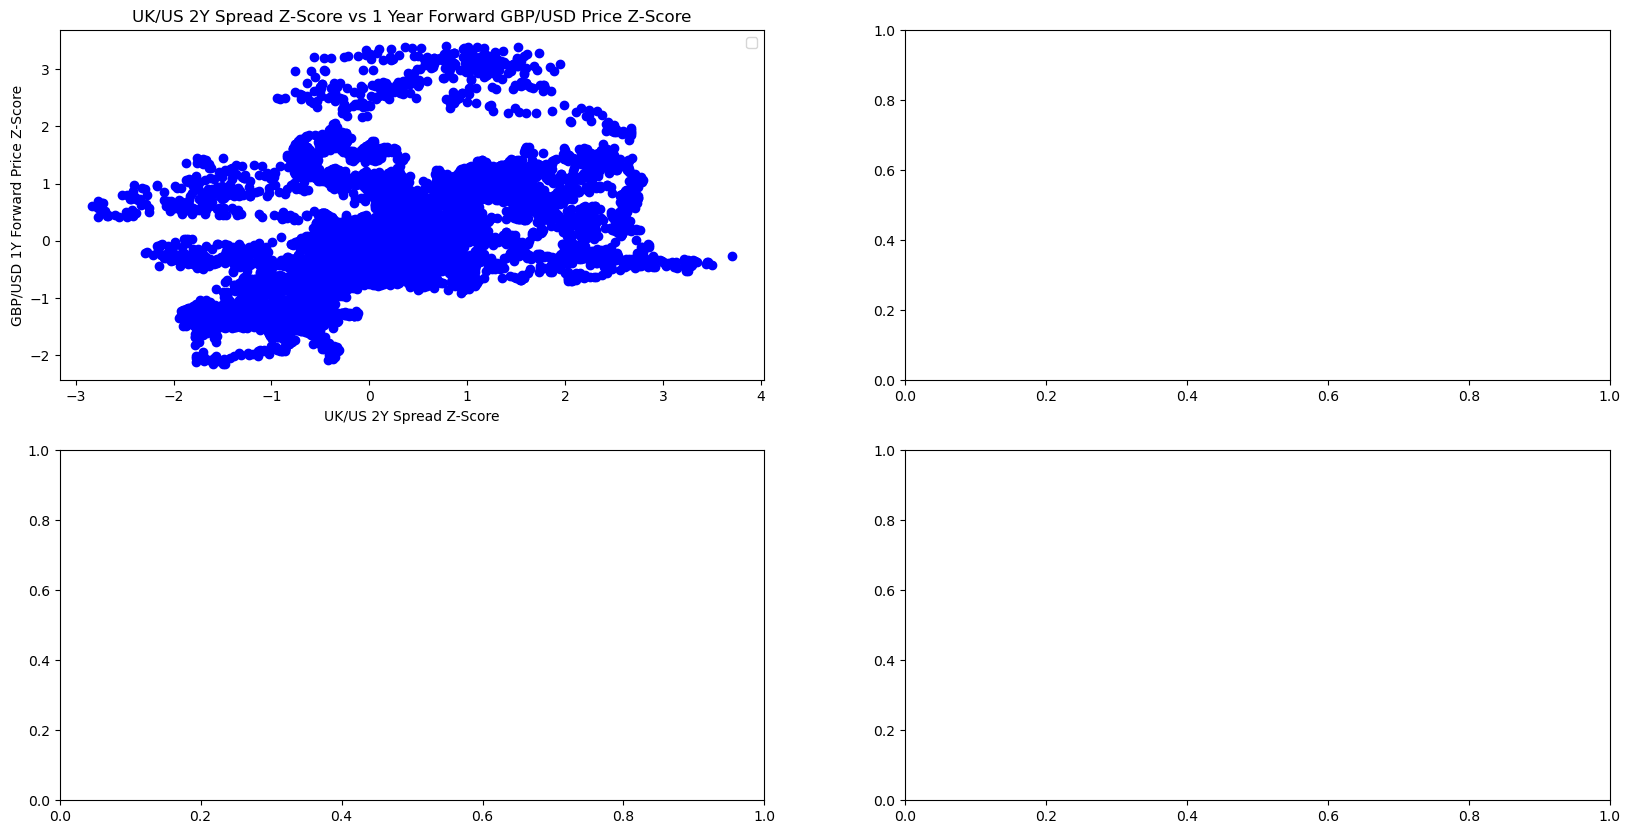

In [37]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10))

gbpusd_zscore.corr(spread_zscore.shift(252*2))
axs[0, 0].set_title("UK/US 2Y Spread Z-Score vs 1 Year Forward GBP/USD Price Z-Score", fontsize=12)
axs[0, 0].scatter(spread_zscore.shift(252), gbpusd_zscore, color="blue")

axs[0, 0].set_xlabel("UK/US 2Y Spread Z-Score")
axs[0, 0].set_ylabel("GBP/USD 1Y Forward Price Z-Score")

# slope, intercept = np.polyfit(spread["spread_abs_change_daily"].iloc[1:-1], np.log(gbpusd["gbp_usd_noon_rate"].shift(-1) / gbpusd["gbp_usd_noon_rate"]).iloc[1:-1], 1)
# x_line = np.linspace(min(spread["spread_abs_change_daily"].iloc[1:-1]), max(spread["spread_abs_change_daily"].iloc[1:-1]), 100)
# y_line = slope * x_line + intercept
# axs[0, 0].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")

axs[0, 0].legend()

# axs[0, 1].set_title("IRD (UK/US 2Y Spread) vs 7 Day Forward GBP/USD Returns", fontsize=12)
# axs[0, 1].scatter(spread["spread_abs_change_daily"], np.log(gbpusd["gbp_usd_noon_rate"].shift(-7) / gbpusd["gbp_usd_noon_rate"]), color="blue")

# axs[0, 1].set_xlabel("IRD (UK/US 2Y Spread Change)")
# axs[0, 1].set_ylabel("GBP/USD 10D Forward Log Returns")

# axs[1, 0].set_title("IRD (UK/US 2Y Spread) vs 20 Day Forward GBP/USD Returns", fontsize=12)
# axs[1, 0].scatter(spread["spread_abs_change_daily"], np.log(gbpusd["gbp_usd_noon_rate"].shift(-20) / gbpusd["gbp_usd_noon_rate"]), color="blue")

# axs[1, 0].set_xlabel("IRD (UK/US 2Y Spread Change)")
# axs[1, 0].set_ylabel("GBP/USD 20D Forward Log Returns")

# axs[1, 1].set_title("IRD (UK/US 2Y Spread) vs 30 Day Forward GBP/USD Returns", fontsize=12)
# axs[1, 1].scatter(spread["spread_abs_change_daily"], np.log(gbpusd["gbp_usd_noon_rate"].shift(-30) / gbpusd["gbp_usd_noon_rate"]), color="blue")

# axs[1, 1].set_xlabel("IRD (UK/US 2Y Spread Change)")
# axs[1, 1].set_ylabel("GBP/USD 30D Forward Log Returns")


## Correlation

#### Contemporaneous

In [38]:
gbpusd_zscore.corr(spread_zscore)

np.float64(0.3743044611806594)

In [39]:
spread["spread_abs_change_daily"].corr(gbpusd["log_return"])

np.float64(0.045897507147514956)

In [40]:
spread_zscore.corr(gbpusd["log_return"])

np.float64(0.030499644134338675)

In [41]:
spread["spread_bp"].corr(gbpusd["log_return"])

np.float64(0.030499644134338644)

- Correlation(Δspread, daily FX returns) ≈ 0.046 → almost no contemporaneous link in short-term changes.


- Correlation(z-scored spread level, z-scored FX price level) ≈ 0.374 → much stronger positive relationship in levels.
    - When UK 2y yields are structurally higher than US 2y yields, GBP/USD tends to trade structurally stronger.
    - About 14% of the variance in GBP/USD levels can be explained by variation in the 2y spread level, if you assume a simple linear relationship.

**Potential Explanations**
- Spreads are a slow-moving macro variable.
- FX returns are fast-moving, noisy.
- If you compare them at the wrong horizon (daily), you mostly get noise. At longer horizons (weekly/monthly), the link might reappear.


#### Lagged

**Lagged Correlation: Change in Yield Spread vs GBP/USD Returns**

In [42]:
for h in [0, 1, 5, 10, 20, 30, 60, 90, 180, 252, 252 * 2, 252 * 3, 252 * 5, 252 * 10]:
    print(f"{h} day ahead correlation: {spread["spread_abs_change_daily"].shift(h).corr(gbpusd["log_return"])}")


0 day ahead correlation: 0.045897507147514956
1 day ahead correlation: 0.03768255088939237
5 day ahead correlation: 0.008697435803764626
10 day ahead correlation: 0.01600000202612878
20 day ahead correlation: -0.007561384366650443
30 day ahead correlation: 0.0039709066491965435
60 day ahead correlation: -0.006702381950156468
90 day ahead correlation: 0.020470543705881687
180 day ahead correlation: 0.027224850309280513
252 day ahead correlation: 0.012532159217582288
504 day ahead correlation: 0.018750332209971812
756 day ahead correlation: 0.011938248243634068
1260 day ahead correlation: -0.0032390019969973437
2520 day ahead correlation: 0.001986255867956733


In [43]:
for h in [0, 1, 5, 10, 20, 30, 60, 90, 180, 252, 252 * 2, 252 * 3, 252 * 5, 252 * 10]:
    print(f"{h} day ahead correlation: {spread_zscore.shift(h).corr(gbpusd["log_return"])}")


0 day ahead correlation: 0.030499644134338675
1 day ahead correlation: 0.027633746418275908
5 day ahead correlation: 0.02313677624652819
10 day ahead correlation: 0.019776942313287246
20 day ahead correlation: 0.016390050684712065
30 day ahead correlation: 0.015474728739381603
60 day ahead correlation: 0.01613639785485315
90 day ahead correlation: 0.0140224279144167
180 day ahead correlation: 0.0020444711392130894
252 day ahead correlation: 0.0008092524682349637
504 day ahead correlation: 0.0035942135535021774
756 day ahead correlation: -0.005345945706899392
1260 day ahead correlation: 0.004531690409688077
2520 day ahead correlation: 0.009080245995057872


**Lagged Correlation: Yield Spread vs GBP/USD**

In [44]:
correlation_varying_lag_time_horizon = pd.Series(
    {h: spread_zscore.shift(h).corr(gbpusd_zscore) for h in range(0, 252*10)}
)

Text(0, 0.5, 'Correlation')

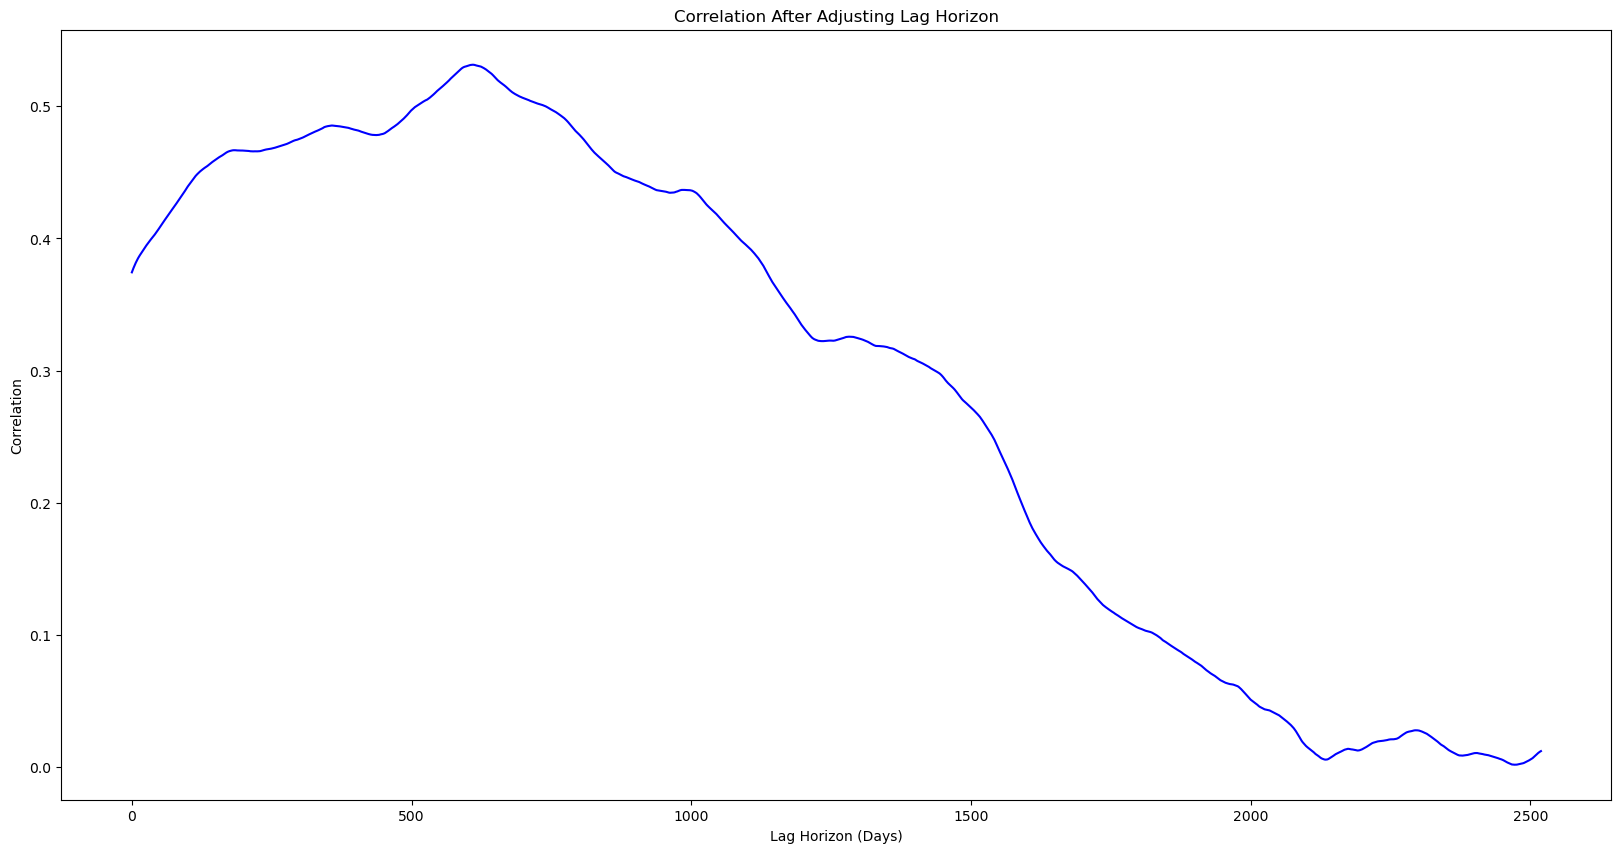

In [45]:
fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("Correlation After Adjusting Lag Horizon", fontsize=12)
axs.plot(correlation_varying_lag_time_horizon, color="blue")

axs.set_xlabel("Lag Horizon (Days)")
axs.set_ylabel("Correlation")

#### Regime Analysis

Line plot would make sense here

In [46]:
spread["spread_abs_change_daily"].rolling(window=252).corr(gbpusd["log_return"]).describe()

count    11923.000000
mean         0.106851
std          0.184188
min         -0.491509
25%          0.026887
50%          0.150869
75%          0.244306
max          0.437911
dtype: float64

In [47]:
spread["spread_abs_change_daily"].shift(10).rolling(window=252).corr(gbpusd["log_return"]).describe()

count    11913.000000
mean         0.004659
std          0.068696
min         -0.190396
25%         -0.043705
50%         -0.003376
75%          0.045183
max          0.237007
dtype: float64

#### Conditionality

Binned average plot (conditional expectation plot)
What it shows: how the size of the spread signal today maps to average forward returns/levels.

How it looks:

X-axis = today’s spread level (binned into quantiles).

Y-axis = average forward FX return (or z-scored level) at a chosen horizon.

Points or bars with error bars (confidence intervals).

Use case: tests monotonicity and economic plausibility. For example: do higher spreads → systematically higher GBP returns over the next 3m, 6m, 12m?

#### Non-Linear Relationship Detection

Any potential for a non-linear relationship between variables?

## Regression Analysis

#### Spread Level vs GBP/USD Level (Z-Score)

In [48]:
X = sm.add_constant(spread_zscore)  # adds a column of 1s for intercept
y = gbpusd_zscore

model = sm.OLS(y, X)   # OLS = Ordinary Least Squares
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      gbp_usd_noon_rate   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     1983.
Date:                Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                        18:40:41   Log-Likelihood:                -16356.
No. Observations:               12175   AIC:                         3.272e+04
Df Residuals:                   12173   BIC:                         3.273e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.464e-16      0.008   4.12e-14      1.000      -0.016       0.016
spread_bp      0.3743      0.008     44.535      0.000       0.358       0.391
==============================================================================
Omnibus:                     2130.068   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3986.499
Skew:                           1.091   Prob(JB):                         0.00
Kurtosis:                       4.759   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Spread Level (Z-Score) vs GBP/USD Returns

In [49]:
spread["spread_abs_change_daily"]

1979-01-01     NaN
1979-01-02    -2.0
1979-01-03     5.0
1979-01-04     5.0
1979-01-05    -4.0
              ... 
2025-08-25    -5.0
2025-08-26    16.0
2025-08-27     0.0
2025-08-28    -5.0
2025-08-29     4.0
Freq: B, Name: spread_abs_change_daily, Length: 12175, dtype: float64

In [50]:
X = sm.add_constant(spread_zscore)  # adds a column of 1s for intercept
y = gbpusd["log_return"]

model = sm.OLS(y, X)   # OLS = Ordinary Least Squares
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     11.33
Date:                Fri, 17 Oct 2025   Prob (F-statistic):           0.000763
Time:                        18:40:41   Log-Likelihood:                 44889.
No. Observations:               12175   AIC:                        -8.977e+04
Df Residuals:                   12173   BIC:                        -8.976e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -3.39e-05   5.49e-05     -0.617      0.537      -0.000    7.38e-05
spread_bp      0.0002   5.49e-05      3.367      0.001    7.73e-05       0.000
==============================================================================
Omnibus:                     1845.874   Durbin-Watson:                   1.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            21833.025
Skew:                          -0.337   Prob(JB):                         0.00
Kurtosis:                       9.526   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Regime Detection

## Next Steps

- Use weekly & monthly time horizons for Spread and FX
    - Spreads evolve relatively slowly (policy expectations don’t flip every day).
    - FX returns are very noisy day-to-day, buffeted by flows, positioning, risk sentiment, etc.
    - At the daily frequency, you’re trying to line up a slow signal with a noisy variable → correlation collapses.
    - At weekly or monthly horizons, the noise cancels out and the structural link between changes in spreads and FX might re-emerge.
- On a daily time horizon levels (as measured by z-score) is more useful than changes for this type of signal there is likely too much noise to gain any useful insight, better off repeating the analysis with weekly or monthly data